## Predicting Telco Customer Churn



## Introduction
In this project, we explore how to identify the most effective machine learning model for predicting customer churn using the Telco Customer Churn dataset [Kaggle Telco Churn Dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data). The process begins with understanding the structure and characteristics of the dataset, followed by examining important patterns, behaviors, and relationships that may influence a customer’s decision to leave a service provider. Afterward, we prepare and refine the data so it can be accurately processed by various machine learning algorithms. Several classification models are then tested and compared to determine which one provides the strongest predictive performance. Finally, the selected model is thoroughly evaluated to ensure its reliability and usefulness in predicting customer churn.

## Variable Description
- **customerID**: unique identifier assigned to each customer.
- **gender**: customer gender (Male, Female).
- **SeniorCitizen**: whether the customer is a senior citizen or not (1 = Yes, 0 = No).
- **Partner**: whether the customer has a partner or not (Yes, No).
- **Dependents**: whether the customer has dependents or not (Yes, No).
- **tenure**: number of months the customer has stayed with the company.
- **PhoneService**: whether the customer has a phone service or not (Yes, No).
- **MultipleLines**: whether the customer has multiple lines or not (Yes, No, No phone service).
- **InternetService**: cutomer's internet service provider (DSL, Fiber optic, No).
- **OnlineSecurity**: whether the customer has online security or not (Yes, No, No internet service).
- **OnlineBackup**: whether the customer has online backup or not (Yes, No, No internet service).
- **DeviceProtection**: whether the customer has device protection or not (Yes, No, No internet service).
- **TechSupport**: whether the customer has tech support or not (Yes, No, No internet service).
- **StreamingTV**: whether the customer has streaming TV or not (Yes, No, No internet service).
- **StreamingMovies**: whether the customer has streaming movies or not (Yes, No, No internet service).
- **Contract**: the contract term of the customer (Month-to-month, One year, Two year).
- **PaperlessBilling**: whether the customer has paperless billing or not (Yes, No).
- **PaymentMethod**: the customer's payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card).
- **MonthlyCharges**: the amount charged to the customer monthly.
- **TotalCharges**: the total amount charged to the customer.
- **Churn**: whether the customer churned or not (Yes, No).



## Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler

from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
#!pip install catboost
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import confusion_matrix, classification_report

from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.1 MB/s eta 0:00:00


## Read Dataset


In [ ]:
df = pd.read_csv('data/Telco-Customer-Churn.csv')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Male,0,y,No,1.0,No,No phone service,Fiberoptic,No,...,No,No,No,No,month to month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,m,0,NO,No,34.0,Yes,No,Fiberoptic,Yes,...,Yes,No,No,No,Two Year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,YES,No,2.0,Yes,No,dsl,Yes,...,No,No,No,No,2 Year,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Female,0,Yes,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,1 year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Male,0,no,NaN,2.0,Yes,No,fiber,No,...,No,No,No,No,Month-to-Month,Yes,Electronic check,70.70,151.65,Yes


## Data Understanding

### Dataset Dimension

In [ ]:
n_row, n_col = df.shape
print(f"Number of rows: {n_row}")
print(f"Number of columns: {n_col}")

Number of rows: 7043
Number of columns: 21


### Columns in Dataset

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### Check Data Types

In [ ]:
col_types = df.dtypes.reset_index()
col_types.columns = ['Column', 'Type']

print("Data type of each column:")
display(col_types)

Data type of each column:


,Column,Type
0,customerID,object
1,gender,object
2,SeniorCitizen,int64
3,Partner,object
4,Dependents,object
5,tenure,float64
6,PhoneService,object
7,MultipleLines,object
8,InternetService,object
9,OnlineSecurity,object


The **TotalCharges** column represents the total amount charged to a customer. Since it stores numerical values, its data type should be **float** rather than **object**.

### Check Duplicate

In [ ]:
dup = df.duplicated().sum()
print("Duplicated Row: ", dup)

Duplicated Row:  0


No duplicate in this dataset

### Check Missing Values

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,453
tenure,455
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


There are several columns with missing values, such as Dependents, tenure, PaperlessBilling, MonthlyCharges, and TotalCharges.

### Check Invalid Values in Numerical Columns

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,6588.000000,6602.000000
mean,0.162147,32.388737,64.747766
std,0.368612,24.569428,30.109079
min,0.000000,0.000000,18.400000
25%,0.000000,9.000000,35.400000
50%,0.000000,29.000000,70.350000
75%,0.000000,56.000000,89.900000
max,1.000000,72.000000,118.750000


The results indicate that there are no invalid values within our numerical columns. Based on the minimum and maximum values across all features, we found no negative values, confirming that the data is within a realistic range. In the Senior Citizen column, the values are limited to 0 and 1, consistent with its format as a binary variable.

### Check Inconsistent in Categorical Values

In [ ]:
categorical_col = df.select_dtypes(exclude=['int64', 'float64']).columns.drop('TotalCharges')

In [ ]:
for col in categorical_col:
  print("Total Unique Values: ", df[col].nunique())
  print(df[col].value_counts(), "\n")

Total Unique Values:  7043
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64 

Total Unique Values:  6
gender
Male       1984
fe male    1057
Female     1034
FEMALE     1012
m           981
f           975
Name: count, dtype: int64 

Total Unique Values:  7
Partner
Yes    1736
No      938
YES     906
NO      893
n       878
y       876
no      816
Name: count, dtype: int64 

Total Unique Values:  2
Dependents
No     4621
Yes    1969
Name: count, dtype: int64 

Total Unique Values:  2
PhoneService
Yes    6361
No      682
Name: count, dtype: int64 

Total Unique Values:  3
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64 

Total Unique Values:  7
InternetService
Fiberoptic     1049
Dsl            1015
fiber optic    1010
DSL            1009
dsl     

We can see that there're inconsistent values in several columns, such as gender, Partner, InternetService, and Contract

## Data Preprocessing

### Handling Data Type

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

Here we convert TotalCharges column from object to float data type using pd.to_numeric

### Handling Inconsistencies

The gender column contains inconsistent entries due to variations in capitalization and spelling, such as "fe male", "FEMALE", and "f". These values are standardized by replacing them with "Female", and "m" is replaced with "Male". This ensures consistency in the categorical data and avoids errors in analysis or modeling.


In [ ]:
# Handle inconsistency in column gender
df["gender"] = df["gender"].replace("fe male", "Female")
df["gender"] = df["gender"].replace("FEMALE", "Female")
df["gender"] = df["gender"].replace("f", "Female")

df["gender"] = df["gender"].replace("m", "Male")

In [ ]:
df["gender"].value_counts()

,count
gender,
Female,4078
Male,2965


The InternetService column contains inconsistent entries due to variations in spelling and capitalization, such as "Fiberoptic", "fiber optic", "fiber", "Dsl", and "dsl". These values are standardized by replacing them with "Fiber Optic" and "DSL" accordingly. This ensures consistent categorical data, which is important for accurate analysis and modeling.

In [ ]:
# Handle inconsistency in column InternetServices
df["InternetService"] = df["InternetService"].replace("Fiberoptic", "Fiber Optic")
df["InternetService"] = df["InternetService"].replace("fiber optic", "Fiber Optic")
df["InternetService"] = df["InternetService"].replace("fiber", "Fiber Optic")

df["InternetService"] = df["InternetService"].replace("Dsl", "DSL")
df["InternetService"] = df["InternetService"].replace("dsl", "DSL")

In [ ]:
df["InternetService"].value_counts()

,count
InternetService,
Fiber Optic,4026
DSL,3017


The Partner column contains inconsistent entries due to variations in capitalization and shorthand, such as "YES", "y", "NO", "n", and "no". These values are standardized by replacing them with "Yes" and "No" accordingly. This ensures consistent categorical values, which is important for accurate analysis and modeling.

In [ ]:
# Handle inconsistency in Partner
df["Partner"] = df["Partner"].replace("YES", "Yes")
df["Partner"] = df["Partner"].replace("y", "Yes")

df["Partner"] = df["Partner"].replace("NO", "No")
df["Partner"] = df["Partner"].replace("n", "No")
df["Partner"] = df["Partner"].replace("no", "No")

In [ ]:
df["Partner"].value_counts()

,count
Partner,
No,3525
Yes,3518


The Contract column contains inconsistent entries due to variations in capitalization and formatting, such as "1 Year", "1 year", "2 Year", "2 year", and "month to month". These values are standardized by replacing them with "One Year", "Two Year", and "Month-to-Month"` accordingly. This ensures consistent categorical values for accurate analysis and modeling.


In [ ]:
# Handle inconsistency in column Contract
df["Contract"] = df["Contract"].replace("1 Year", "One Year")
df["Contract"] = df["Contract"].replace("1 year", "One Year")
df["Contract"] = df["Contract"].replace("2 Year", "Two Year")
df["Contract"] = df["Contract"].replace("2 year", "Two Year")

df["Contract"] = df["Contract"].replace("month to month", "Month-to-Month")

In [ ]:
df["Contract"].value_counts()

,count
Contract,
One Year,2641
Two Year,2614
Month-to-Month,1788


### Drop Data with Tenure = 0

In [ ]:
df0 = df[df['tenure'] != 0]

Observations with tenure = 0 were excluded since the churn status cannot be reliably defined at this stage, potentially introducing bias into the classification model.

### Handling Missing Value Monthly Charges with tenure = 1

In [ ]:
mask = (df0['tenure'] == 1) & (df0['MonthlyCharges'].isnull())
df0.loc[mask, 'MonthlyCharges'] = df0.loc[mask, 'TotalCharges']

Because customers with a tenure of 1 have missing values in MonthlyCharges, the MonthlyCharges value can be imputed using TotalCharges, since in the first month, the total cost is generally equal to the monthly charge.

## EDA

### Check Correlation

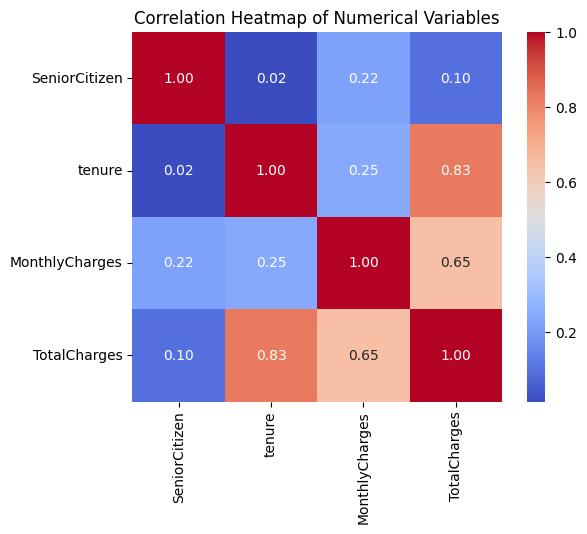

In [ ]:
numeric_col = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_col.corr()

sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", square = True)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

**TotalCharges is largely driven by tenure and monthly charges**, which aligns with how biling naturally accumulates. **MonthlyCharges and tenure are not strongly related**, meaning the length of stay does not determine what type of plan customers choose. **SeniorCitizen has no significant correlation with other numerical variables**, so its impact on churn does not stem from tenure or biling behavior.

Because tenure and TotalCharges are highly correlated, one of these variables should be removed to avoid **multicollinearity**, which can distort model coefficients and reduce model interpretability. Since TotalCharges is largely derived from tenure and monthly charges, keeping both features would introduce redundant information. Therefore, only one of them should be retained in the model.

To evaluate the relationship between numerical features and the target variable (Churn), p-values obtained from statistical hypothesis testing are used. Specifically, the Mann–Whitney U test is applied. This non-parametric test was chosen because it does not require any assumption about the underlying distribution of the numerical variables, making it robust to non-normal data and the presence of outliers.

In the Mann–Whitney U test, for each numerical feature, the dataset is divided into two independent samples based on the churn label (churned and non-churned customers). The test compares the distributions of the two samples without assuming normality. The U-statistic and the corresponding p-value are computed and stored for further analysis. A low p-value indicates that the numerical feature shows a statistically significant association with customer churn.



### Check Association Between Numerical Variables and Categorical Target Variable

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).drop(columns=['SeniorCitizen'], errors='ignore').columns

results = []

for col in num_cols:
    x0 = df[df['Churn'] == 'No'][col].dropna()
    x1 = df[df['Churn'] == 'Yes'][col].dropna()

    if len(x0) > 0 and len(x1) > 0:
        u, p = mannwhitneyu(x0, x1, alternative='two-sided')
        results.append([col, u, p])

mw_df = pd.DataFrame(results, columns=['column', 'U_statistic', 'p_value'])
mw_df.sort_values(by='p_value')

,column,U_statistic,p_value
0,tenure,6269176.5,2.711484e-194
2,TotalCharges,5444030.0,5.522277e-79
1,MonthlyCharges,3250157.5,2.610251e-49


The p-value of tenure is lower than the p-value of TotalCharges, tenure shows a stronger statistical significance to Churn. Therefore, TotalCharges can be dropped.

### Check Association Between Categorical Variables

In [ ]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

In [ ]:
def cramers_v_matrix(df, categorical_cols):
    result = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

    for col1 in categorical_cols:
        for col2 in categorical_cols:
            result.loc[col1, col2] = cramers_v(df[col1], df[col2])

    return result.astype(float)

In [ ]:
cat_cols = df.select_dtypes(include=["object"]).columns
cat_cols = [c for c in cat_cols if c not in ["Churn", "customerID"]]

cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramers_matrix = cramers_matrix.astype(float)

print("Cramer's V Matrix:")
cramers_matrix.round(2)

Cramer's V Matrix:


,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
gender,1.00,0.01,0.02,0.01,0.02,0.01,0.00,0.02,0.01,0.00,0.02,0.00,0.03,0.01,0.02
Partner,0.01,1.00,0.02,0.02,0.03,0.01,0.02,0.02,0.02,0.03,0.02,0.02,0.03,0.01,0.02
Dependents,0.02,0.02,1.00,0.00,0.02,0.02,0.19,0.16,0.15,0.18,0.15,0.14,0.01,0.11,0.15
PhoneService,0.01,0.02,0.00,1.00,1.00,0.02,0.18,0.17,0.17,0.18,0.18,0.18,0.01,0.02,0.01
MultipleLines,0.02,0.03,0.02,1.00,1.00,0.02,0.23,0.25,0.25,0.23,0.26,0.26,0.02,0.17,0.17
InternetService,0.01,0.01,0.02,0.02,0.02,1.00,0.02,0.01,0.00,0.02,0.01,0.02,0.02,0.01,0.02
OnlineSecurity,0.00,0.02,0.19,0.18,0.23,0.02,1.00,0.72,0.72,0.73,0.71,0.71,0.02,0.34,0.30
OnlineBackup,0.02,0.02,0.16,0.17,0.25,0.01,0.72,1.00,0.72,0.72,0.71,0.71,0.02,0.32,0.28
DeviceProtection,0.01,0.02,0.15,0.17,0.25,0.00,0.72,0.72,1.00,0.73,0.73,0.74,0.02,0.32,0.29
TechSupport,0.00,0.03,0.18,0.18,0.23,0.02,0.73,0.72,0.73,1.00,0.72,0.72,0.02,0.33,0.31


There is **a strong cluster of internet-related services (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies)** because these features depend on whether the customer has internet service. There is **a moderate association between digital behaviors (PaperlessBilling, PaymentMethod)** and additional internet services, meaning customers who are more digitally active tend to use more digital add-ons. **Demographic variables like gender, partner, and dependents show very weak relationships** with other variables, meaning they do not influence service choices much. **Contract type and phone-service-related variables have weak associations** with most other features, indicating these services are chosen more independently.

In [ ]:
print("Cramer’s V between categorical features and churn")

cramer_results = {}

for col in cat_cols:
    cramer_results[col] = cramers_v(df[col], df["Churn"])

cramer_df = pd.DataFrame.from_dict(cramer_results, orient="index", columns=["Cramers_V"])
print(cramer_df.sort_values("Cramers_V", ascending=False).round(3))


Cramer’s V between categorical features and churn
                  Cramers_V
OnlineSecurity        0.347
TechSupport           0.343
PaymentMethod         0.303
OnlineBackup          0.292
DeviceProtection      0.282
StreamingMovies       0.231
StreamingTV           0.231
PaperlessBilling      0.195
Dependents            0.160
MultipleLines         0.040
InternetService       0.014
PhoneService          0.011
gender                0.010
Partner               0.009
Contract              0.005


The **strongest churn predictors** come from **internet security and support services** (such as OnlineSecurity and TechSupport), payment methods, and digital entertainment services. In contrast, **demographic variables and basic services** like phone service, internet service, and multiple lines show **very minimal influence** on churn. This pattern indicates that churn is primarily driven by **service experience quality** and **user convenience** rather than customer characteristics. Therefore, retention strategies should focus on **improving the quality of digital services, enhancing payment convenience, and ensuring that customers clearly perceive added value** from the services they use.

### Distribution

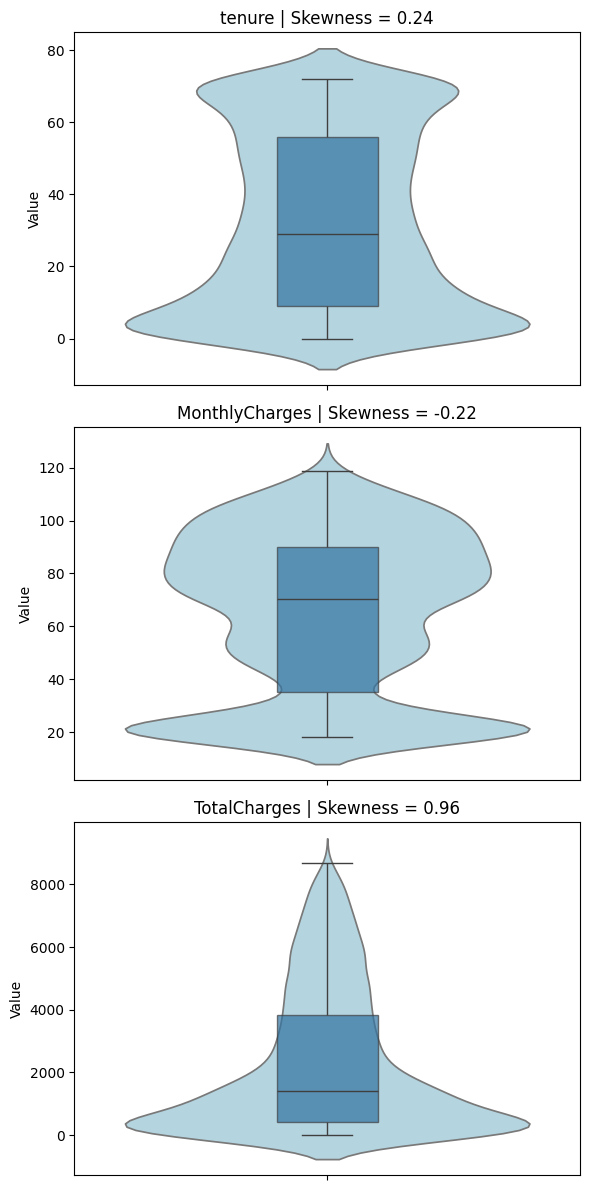

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).drop(columns=['SeniorCitizen'], errors='ignore').columns

plt.figure(figsize=(6, 4 * len(num_cols)))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.violinplot(y=df[col], color="lightblue", inner=None)
    sns.boxplot(y=df[col], width=0.2, boxprops={'alpha': 0.7})

    #plot
    plt.title(f"{col} | Skewness = {df[col].skew():.2f}")
    plt.xlabel("")
    plt.ylabel("Value")

    plt.tight_layout()

plt.show()

**Tenure (skewness = 0.24, slight right-skew) and MonthlyCharges (skewness = -0.22, slight left-skew)** both have low skewness values, indicating stable and well-balanced distributions suitable for modeling. **TotalCharges has a higher skewness of 0.96 (moderately right-skewed)**, primarily driven by variations in customer tenure, reflecting the natural differences in cumulative spending between new and long-term customers. Highly skewed numerical features may negatively affect models that are sensitive to feature scale and distribution, and therefore often require scaling or transformation. However, since TotalCharges was excluded from the final feature set due to multicollinearity, no scaling or transformation was applied to this variable.

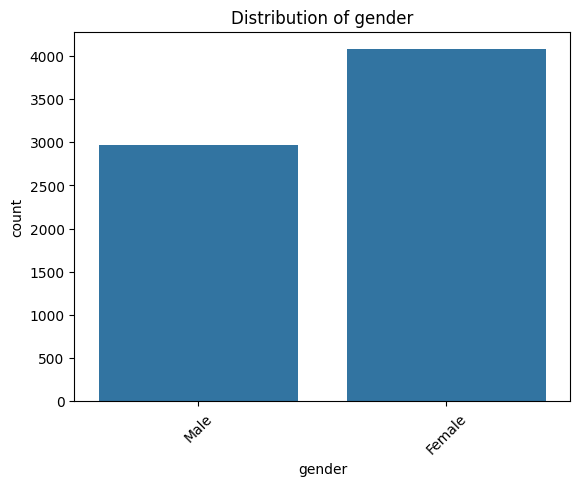

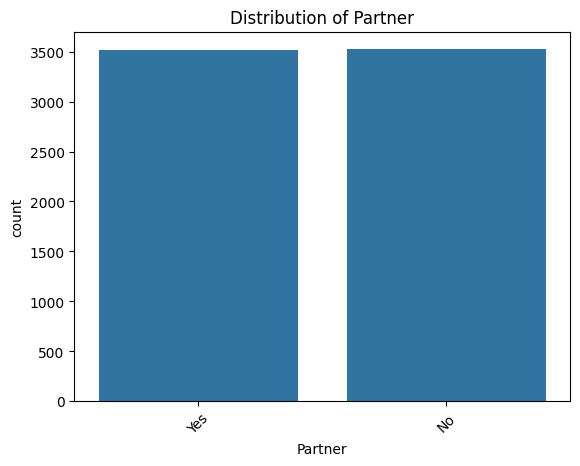

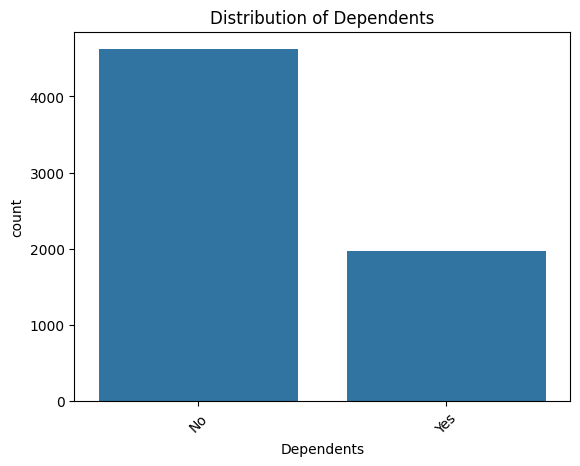

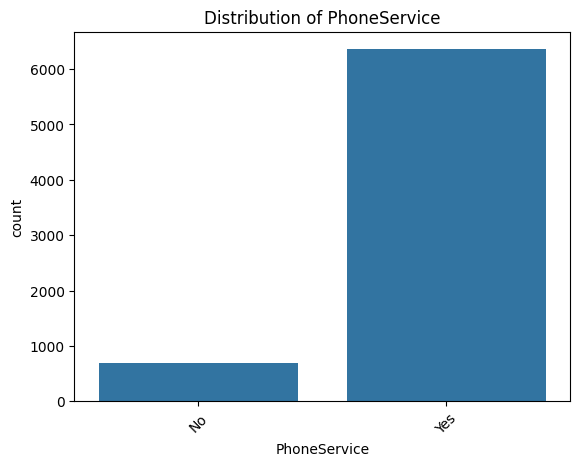

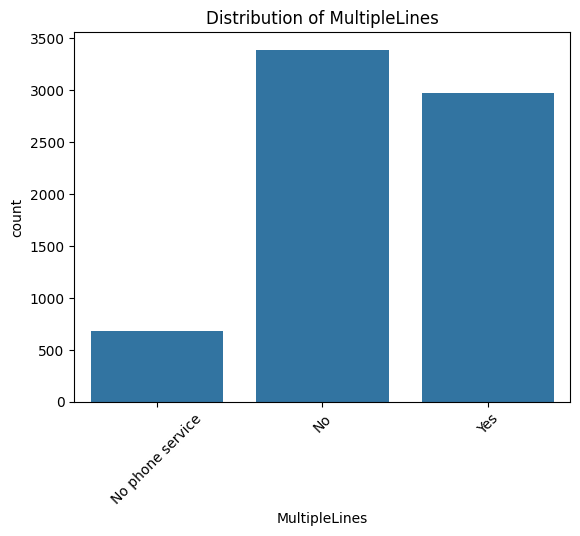

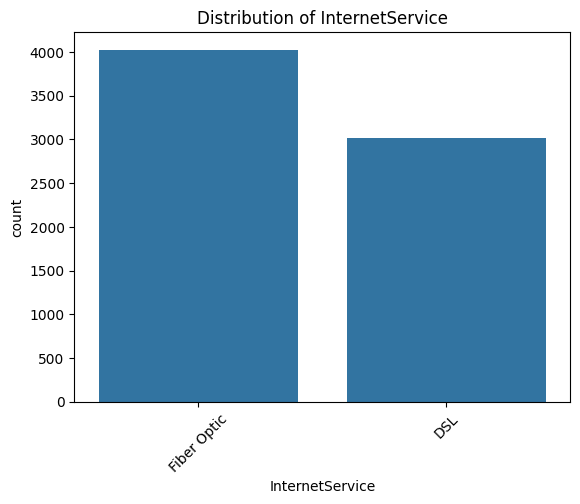

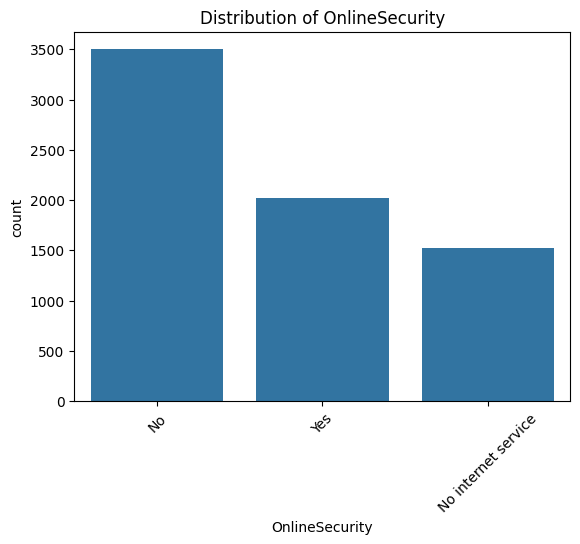

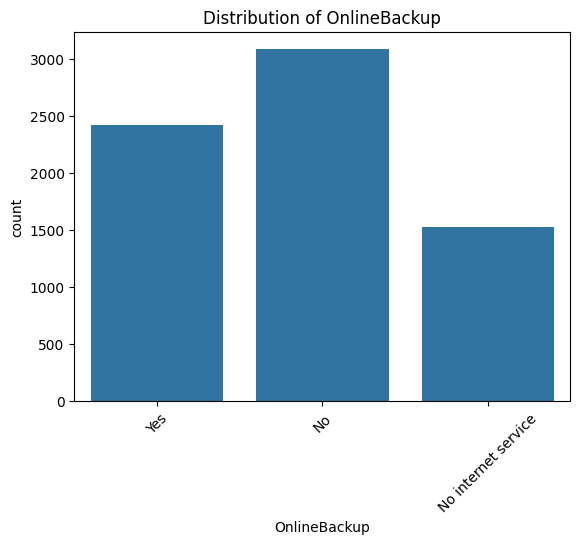

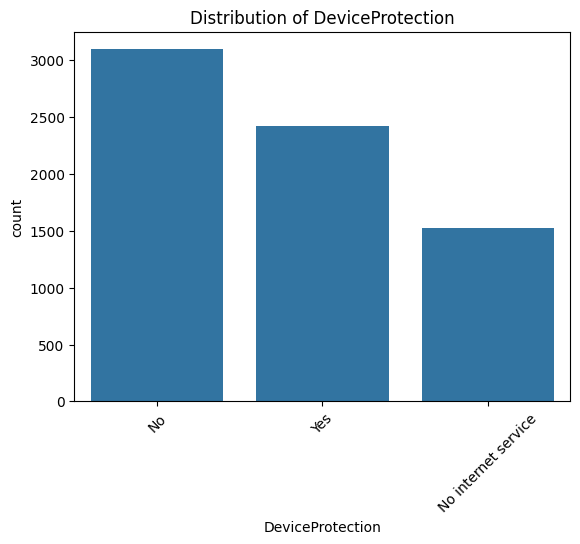

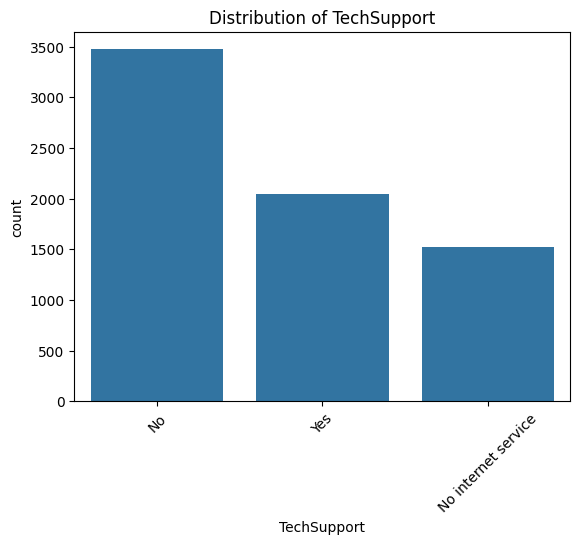

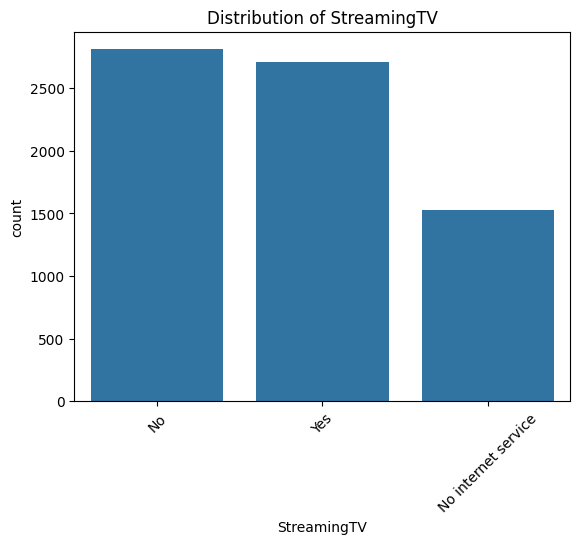

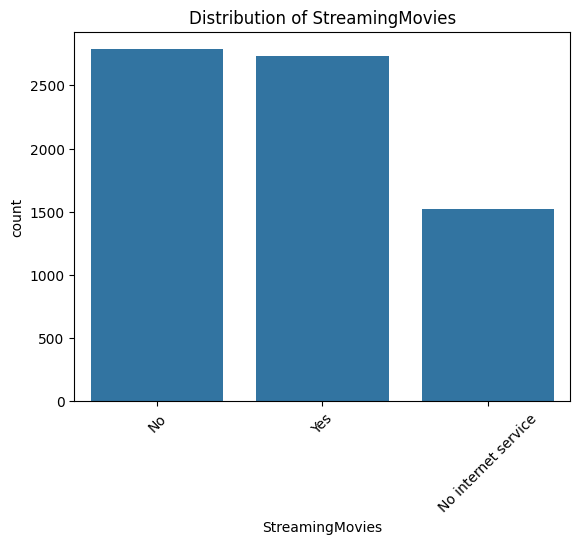

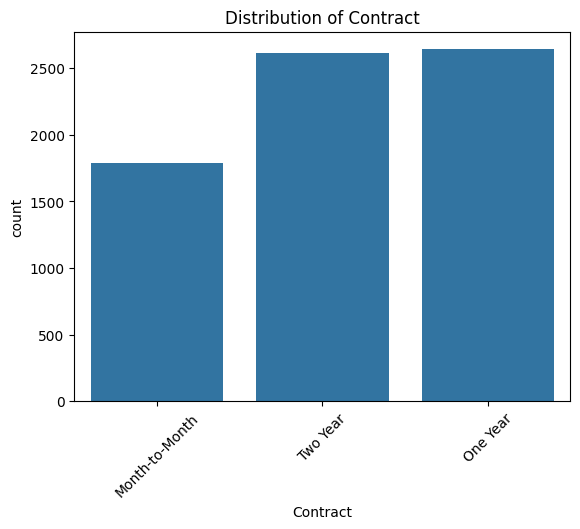

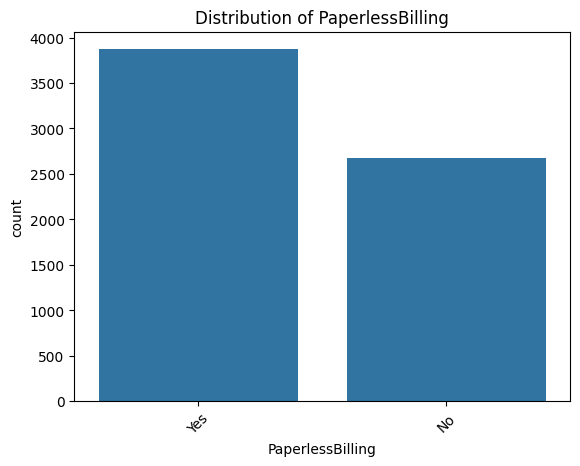

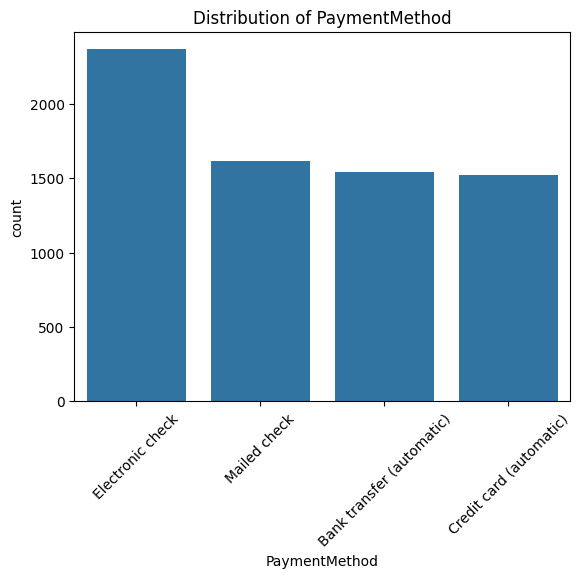

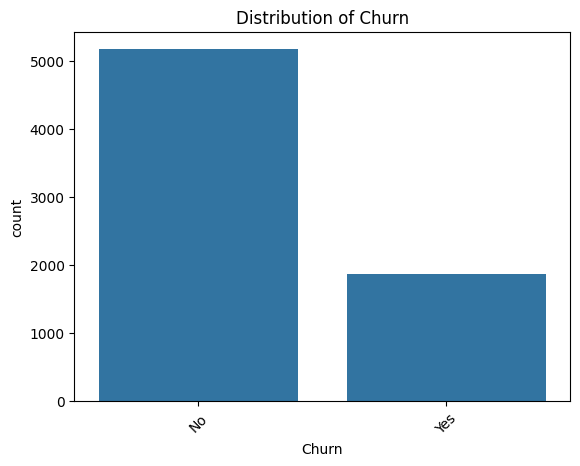

In [ ]:
categorical_col = df.select_dtypes(include=['object']).columns
categorical_col = categorical_col.drop("customerID")

for col in categorical_col:
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

* Distribution of Gender  
The chart shows the distribution of customers by gender. From the visual, it is clear that the number of female customers is higher than the number of male customers. Approximately, there are around 4100 female customers compared to around 3000 male customers.

* Distribution of Partner   
The chart shows the distribution of customers based on whether they have a partner or not. The results show that the number of customers with a partner and without a partner is almost equal, with both groups having approximately 3500 customers each.

* Distribution of Dependents  
The chart shows the distribution of customers based on whether they have dependents or not. Based on the chart, approximately 4800 customers do not have dependents while only around 2000 customers report having dependents.

* Distribution of PhoneService   
The chart shows the distribution of customers based on whether they subscribe to phone service or not. Based on the chart, around 6300 customers subscribe to phone service while only about 700 customers do not subscribe to phone service.

* Distribution of MultipleLines   
The chart shows the distribution of customers based on their subscription to multiple lines service. Based on the chart, around 3400 customers do not have multiple lines, about 3000 customers have multiple lines, and approximately 700 customers have no phone service at all.

* Distribution of InternetService   
The chart shows the distribution of customers based on the type of internet service they use. Based on the chart, around 4000 customers subscribe to Fiber Optic, while approximately 3000 customers use DSL.

* Distribution of OnlineSecurity   
The chart shows the distribution of customers based on their subscription to online security services. Based on the chart, around 3500 customers do not subscribe to online security, about 2000 customers subscribe to online security, and approximately 1500 customers have no internet service.

* Distribution of OnlineBackup   
The chart shows the distribution of customers based on their subscription to online backup services. Based on the chart, around 3100 customers do not subscribe to online backup, about 2400 customers subscribe to online backup, and approximately 1500 customers have no internet service.

* Distribution of DeviceProtection   
The chart shows the distribution of customers based on their subscription to device protection services. Based on the chart, around 3100 customers do not subscribe to device protection, about 2400 customers subscribe to the service, and approximately 1500 customers have no internet service.

* Distribution of TechSupport   
The chart shows the distribution of customers based on their subscription to tech support services. Based on the chart, around 3500 customers do not subscribe to tech support, about 2000 customers subscribe to the service, and approximately 1500 customers have no internet service.

* Distribution of StreamingTV    
The chart shows the distribution of customers based on their subscription to streaming TV services. Based on the chart, around 2800 customers do not subscribe to streaming TV, about 2700 customers subscribe to the service, and approximately 1500 customers have no internet service.

* Distribution of StreamingMovies   
The chart shows the distribution of customers based on their subscription to streaming movie services. Based on the chart, around 2800 customers do not subscribe to streaming movies, about 2750 customers subscribe to the service, and approximately 1500 customers have no internet service.

* Distribution of Contract   
The chart shows the distribution of customers based on their contract type. Based on the chart, around 1800 customers use Month-to-Month contracts, about 2600 customers have Two-Year contracts, and approximately 2650 customers are subscribed to One-Year contracts.

* Distribution of PaperlessBilling   
The chart shows the distribution of customers based on whether they have paperlessbilling or not. Based on the chart, approximately 3800 customers have paperlessbilling while only around 2700 customers do not have paperlessbilling.

* Distribution of PaymentMethod   
The chart shows the distribution of customers based on their payment method. Based on the chart, around 2350 customers use Electronic Check, about 1630 customers use Mailed Check, approximately 1550 customers pay through Bank Transfer (automatic), and around 1520 customers use Credit Card (automatic).

* Distribution of Churn   
The chart shows the distribution of customers based on whether they churned or not. Based on the chart, approximately 5100 customers curned while around 2000 customers not churn. This indicates that the target variable is imbalanced.



### Bivariate

In [ ]:
pd.crosstab(df0['SeniorCitizen'], df0['Churn'], normalize='index') * 100

Churn,No,Yes
SeniorCitizen,,
0,76.357773,23.642227
1,58.318739,41.681261


Based on the crosstab analysis, non-senior citizens (0) have a churn rate of approximately 23.6%, the churn rate for senior citizens (1) is significantly higher at 41.7%. This nearly double increase indicates that senior citizens are a high risk segment, making this feature a strong and meaningful predictor for our churn model.

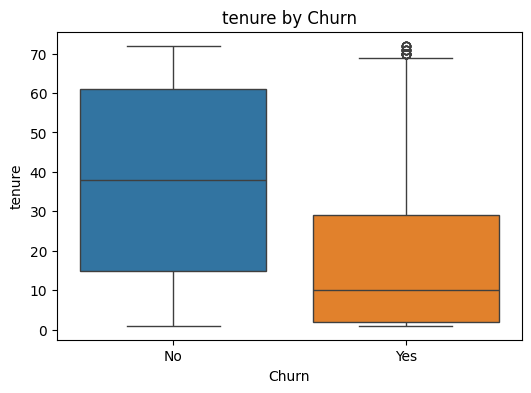

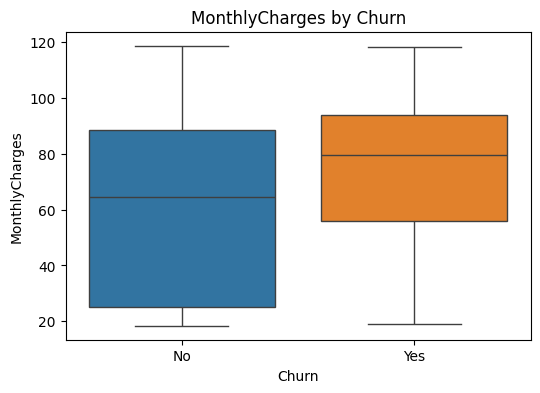

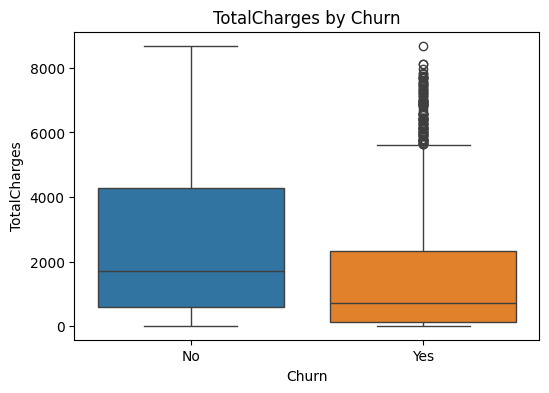

In [ ]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

palette_colors = {"No": "#1f77b4", "Yes": "#ff7f0e"}

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        data=df0,
        x='Churn',
        y=col,
        palette=palette_colors
    )
    plt.title(f"{col} by Churn")
    plt.show()

* tenure by Churn   
The boxplot shows a clear separation in tenure between churned and non-churned customers. Customers who did not churn have a much higher median tenure and a wider distribution, indicating long term engagement and stability. In contrast, churned customers are concentrated at low tenure values, with a median close to the lower end of the scale. This pattern suggests that customer churn predominantly occurs during the early stages of the subscription period, while customers who remain longer tend to be significantly less likely to churn.

* MonthlyCharges by Churn   
The boxplot indicates that churned customers generally incur higher MonthlyCharges compared to non churned customers. The median MonthlyCharges for churned customers is noticeably higher, suggesting that higher recurring costs are associated with an increased likelihood of churn. Non-churned customers, on the other hand, tend to have lower and more dispersed MonthlyCharges, reflecting greater price tolerance or perceived value among retained customers. This highlights pricing pressure as an important contributing factor to churn.

* TotalCharges by Churn   
The boxplot illustrates a clear difference in TotalCharges distribution between churned and non churned customers. Customers who did not churn exhibit substantially higher median TotalCharges and a wider overall distribution, indicating longer service duration and greater cumulative spending. In contrast, churned customers tend to have much lower TotalCharges, with the median concentrated near the lower end of the scale, suggesting that many customers churn early in their subscription period. Although several high value outliers are observed among churned customers, the overall pattern indicates that higher TotalCharges are linked to lower churn likelihood. This reinforces the notion that customer churn predominantly occurs during the early stages of the customer lifecycle, while long-tenure customers are generally more stable and less likely to churn.


===== Crosstab: gender vs Churn =====
Churn          No        Yes
gender                      
Female  73.803094  26.196906
Male    72.914556  27.085444 



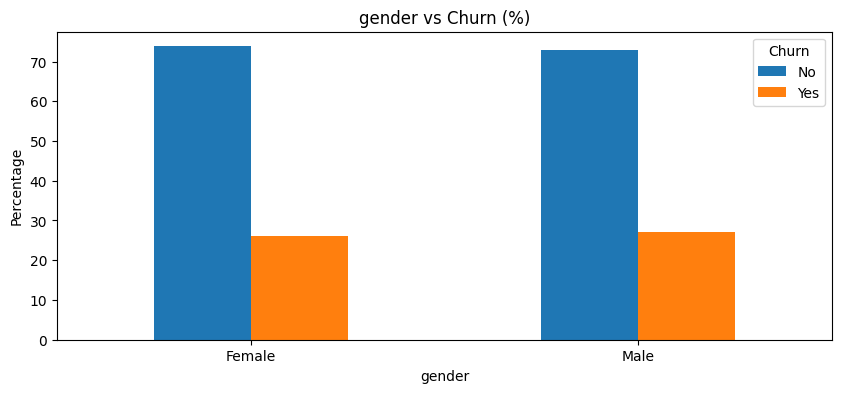

===== Crosstab: Partner vs Churn =====
Churn           No        Yes
Partner                      
No       73.857508  26.142492
Yes      72.999146  27.000854 



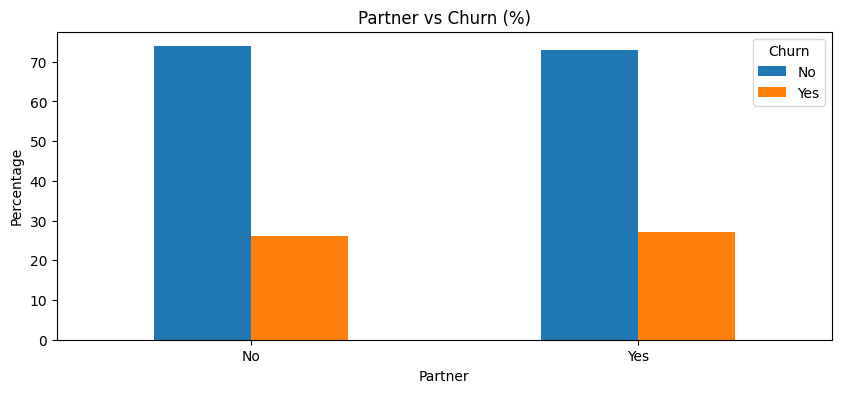

===== Crosstab: Dependents vs Churn =====
Churn              No        Yes
Dependents                      
No          68.946116  31.053884
Yes         84.285714  15.714286 



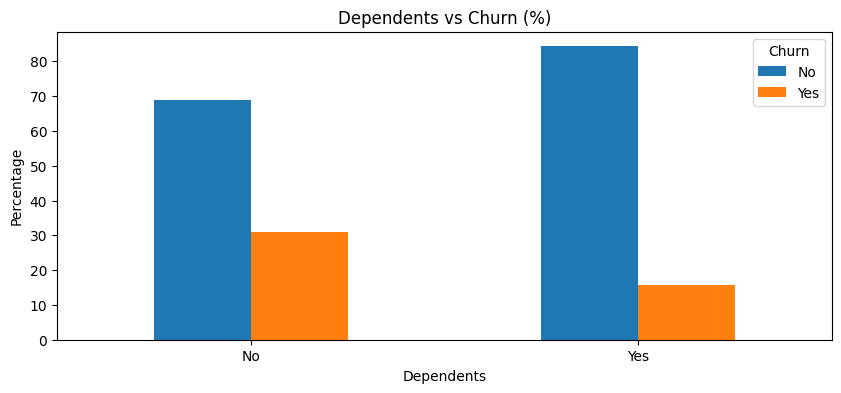

===== Crosstab: PhoneService vs Churn =====
Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.252519  26.747481 



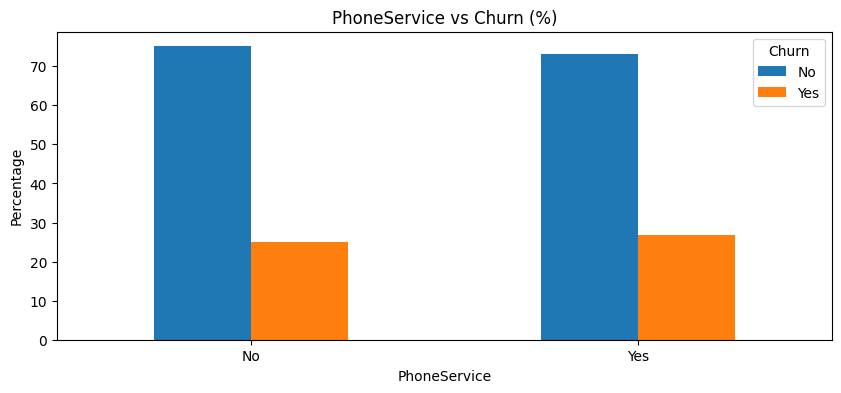

===== Crosstab: MultipleLines vs Churn =====
Churn                    No        Yes
MultipleLines                         
No                74.918759  25.081241
No phone service  75.073314  24.926686
Yes               71.351534  28.648466 



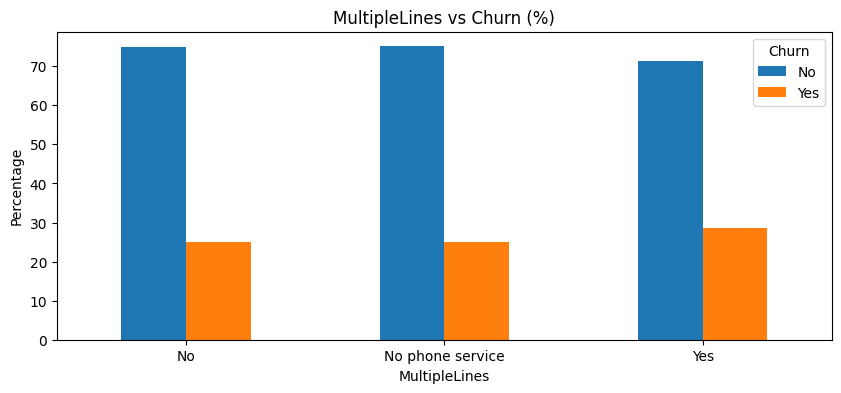

===== Crosstab: InternetService vs Churn =====
Churn                   No        Yes
InternetService                      
DSL              72.666888  27.333112
Fiber Optic      73.999503  26.000497 



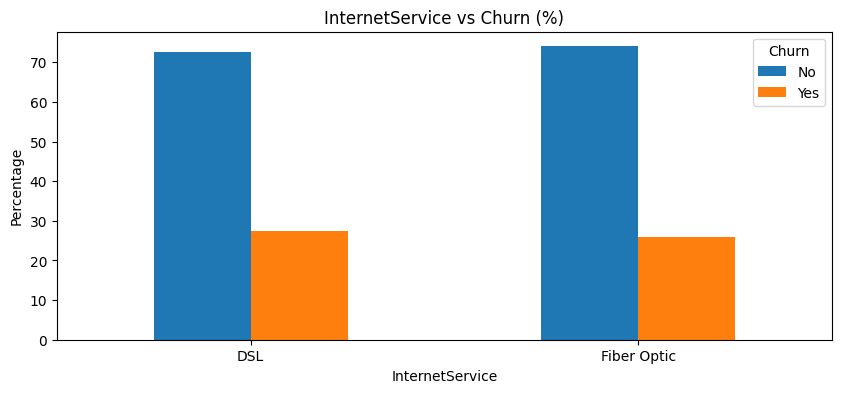

===== Crosstab: OnlineSecurity vs Churn =====
Churn                       No        Yes
OnlineSecurity                           
No                   58.221333  41.778667
No internet service  92.565789   7.434211
Yes                  85.374318  14.625682 



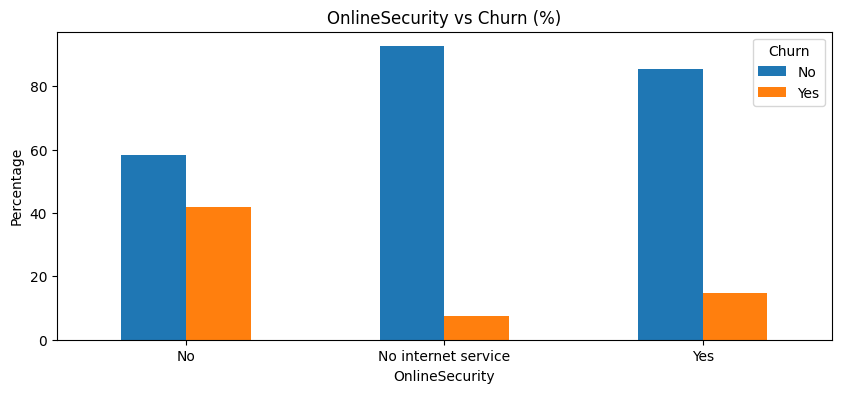

===== Crosstab: OnlineBackup vs Churn =====
Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.565789   7.434211
Yes                  78.441880  21.558120 



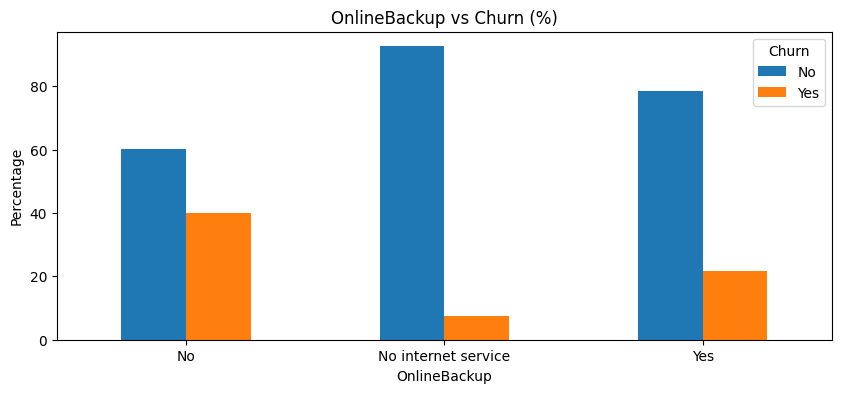

===== Crosstab: DeviceProtection vs Churn =====
Churn                       No        Yes
DeviceProtection                         
No                   60.859729  39.140271
No internet service  92.565789   7.434211
Yes                  77.479339  22.520661 



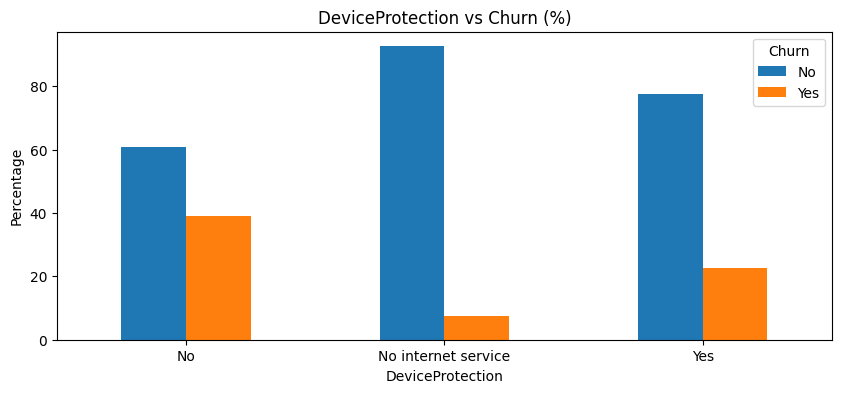

===== Crosstab: TechSupport vs Churn =====
Churn                       No        Yes
TechSupport                              
No                   58.352535  41.647465
No internet service  92.565789   7.434211
Yes                  84.818805  15.181195 



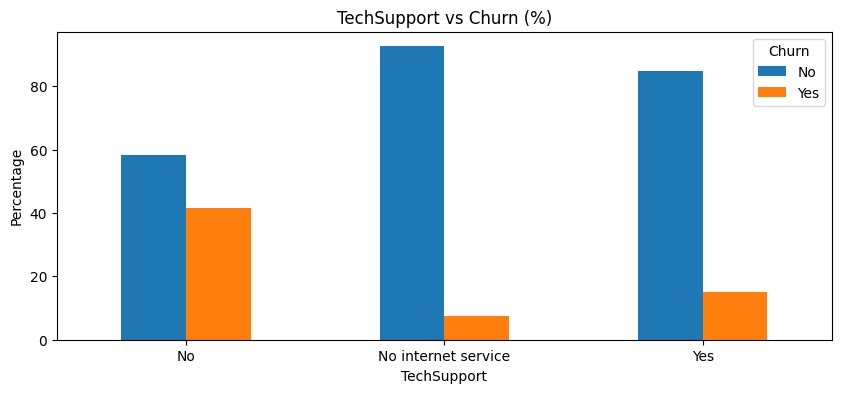

===== Crosstab: StreamingTV vs Churn =====
Churn                       No        Yes
StreamingTV                              
No                   66.464934  33.535066
No internet service  92.565789   7.434211
Yes                  69.907579  30.092421 



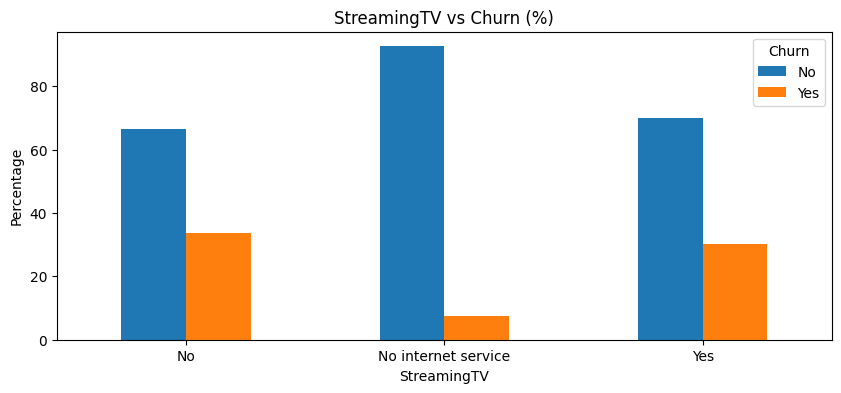

===== Crosstab: StreamingMovies vs Churn =====
Churn                       No        Yes
StreamingMovies                          
No                   66.295365  33.704635
No internet service  92.565789   7.434211
Yes                  70.047602  29.952398 



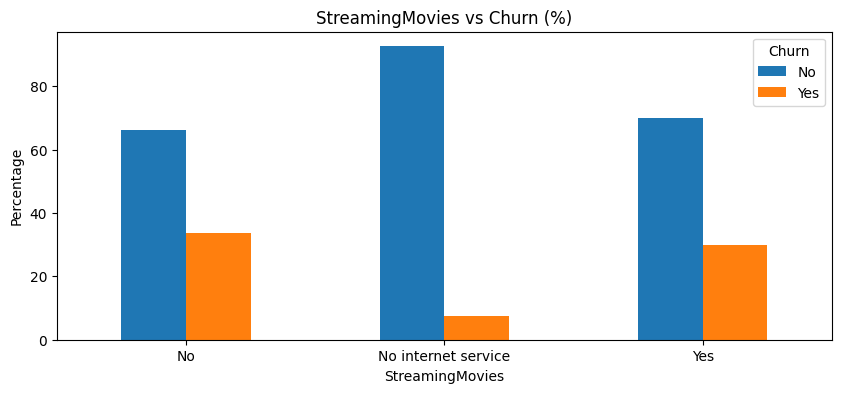

===== Crosstab: Contract vs Churn =====
Churn                  No        Yes
Contract                            
Month-to-Month  73.053221  26.946779
One Year        73.474801  26.525199
Two Year        73.639847  26.360153 



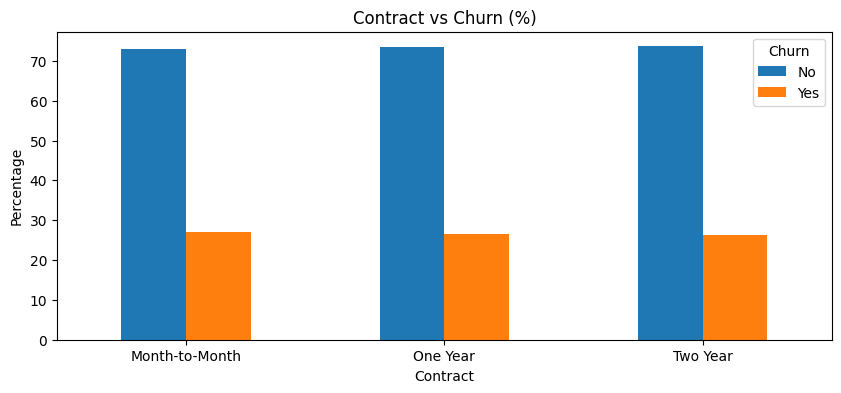

===== Crosstab: PaperlessBilling vs Churn =====
Churn                    No        Yes
PaperlessBilling                      
No                83.863721  16.136279
Yes               66.330749  33.669251 



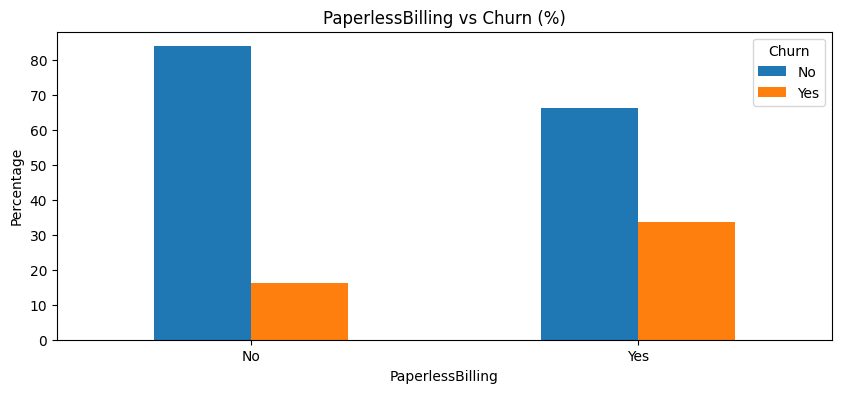

===== Crosstab: PaymentMethod vs Churn =====
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.279326  16.720674
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.798005  19.201995 



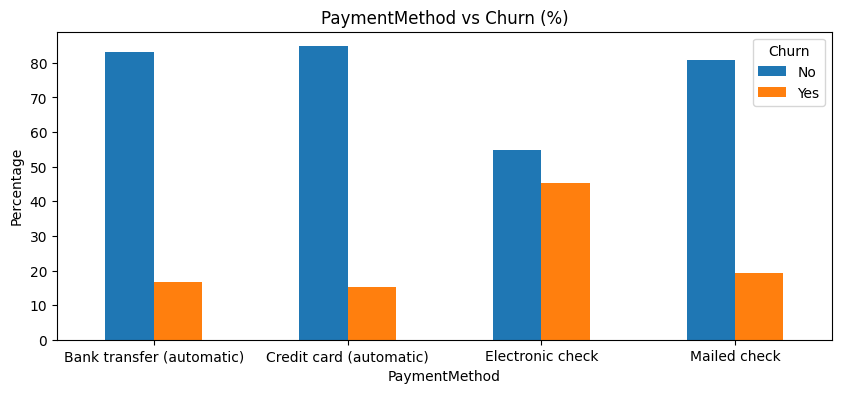

===== Crosstab: SeniorCitizen vs Churn =====
Churn                 No        Yes
SeniorCitizen                      
0              76.357773  23.642227
1              58.318739  41.681261 



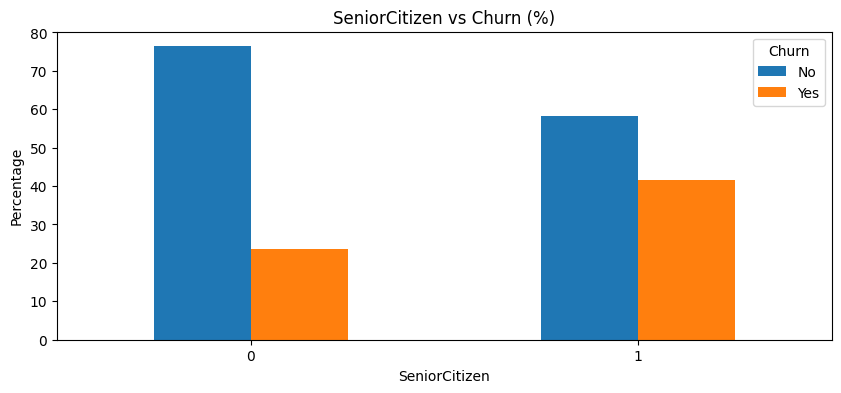

In [ ]:
df_biv = df0.copy()

categorical_cols = df_biv.select_dtypes(include='object').columns.tolist()
drop_cols = ["customerID", "Churn"]
categorical_cols = [col for col in categorical_cols if col not in drop_cols]
df_biv["SeniorCitizen"] = df_biv["SeniorCitizen"].astype("category")
categorical_cols.append("SeniorCitizen")
categorical_cols

for col in categorical_cols:
  print(f"===== Crosstab: {col} vs Churn =====")

  ct = pd.crosstab(df_biv[col], df_biv["Churn"], normalize='index') * 100
  print(ct, "\n")

  ct.plot(kind='bar', figsize=(10,4))
  plt.title(f"{col} vs Churn (%)")
  plt.ylabel("Percentage")
  plt.xticks(rotation=0)
  plt.legend(title="Churn")
  plt.show()

* gender vs Churn  
The plot indicates that churn rates are relatively similar between male and female customers. Female customers exhibit a churn rate of approximately 26.2%, while male customers show a slightly higher churn rate of about 27.1%. The difference between the two groups is minimal, suggesting that gender does not play a significant role in determining churn behavior.

* Partner vs Churn  
The plot reveals a clearer distinction in churn behavior based on partner status. Customers without a partner experience a lower retention rate and a higher churn rate (approximately 26.1%) compared to customers with a partner, whose churn rate is around 27.0%. Although the difference is not large, it suggests that partner status may have a modest association with churn, potentially reflecting greater stability or shared decision making among partnered customers.

* Dependents vs Churn  
The plot shows a clear and meaningful difference in churn behavior based on dependent status. Customers without dependents exhibit a significantly higher churn rate (approximately 31.1%) compared to customers with dependents, whose churn rate is substantially lower at around 15.7%. This indicates that customers with dependents tend to be more stable and less likely to churn, possibly due to higher switching costs or a greater need for reliable services. As a result, dependent status appears to be a relevant categorical factor associated with customer retention.

* PhoneService vs Churn  
The plot indicates that phone service subscription alone does not strongly differentiate churn behavior. Customers without phone service show a churn rate of approximately 24.9%, while those with phone service exhibit a slightly higher churn rate of around 26.7%. The relatively small difference suggests that PhoneService has a weak association with churn, implying that churn is influenced more by other service features or contractual factors rather than the presence of basic phone service.

* MultipleLines vs Churn  
The plot shows that customers with multiple lines exhibit a slightly higher churn rate compared to those without multiple lines or those with no phone service. While the churn rate for customers without multiple lines and those with no phone service is relatively similar (around the mid-20% range), customers with multiple lines show a modest increase in churn (28.6%). This suggests that having multiple phone lines does not strongly reduce churn risk and may even be associated with higher churn, potentially due to higher costs or increased service complexity. Overall, the association between MultipleLines and churn appears moderate to weak.

* InternetService vs Churn  
The plot indicates that churn rates are broadly similar across different Internet Service types, with DSL customers exhibiting a churn rate of approximately 27.3% and Fiber Optic customers around 26.0%. The difference between the two groups is relatively small, suggesting that Internet Service type alone is not a strong determinant of churn. This implies that churn behavior is likely influenced more by complementary services (such as Online Security) or pricing factors rather than the underlying internet technology itself. This pattern indicates that Online Security acts as a protective service, increasing customer retention by reducing churn risk. Customers lacking this feature are more vulnerable to churn, possibly due to concerns over security, service value, or dissatisfaction. Consequently, Online Security appears to be a highly influential feature in predicting churn.

* OnlineSecurity vs Churn  
The plot demonstrates a strong relationship between Online Security and customer churn. Customers without Online Security exhibit a substantially higher churn rate (around 41.8%) compared to those with Online Security, whose churn rate is significantly lower (approximately 14.6%). Meanwhile, customers with no internet service show the lowest churn rate (about 7.4%), which is expected as they are not exposed to internet-related service issues. This pattern indicates that Online Security acts as a protective service, increasing customer retention by reducing churn risk. Customers lacking this feature are more vulnerable to churn, possibly due to concerns over security, service value, or dissatisfaction. Consequently, Online Security appears to be a highly influential feature in predicting churn.

* OnlineBackup vs Churn  
A similar trend is observed in the Online Backup plot. Customers without Online Backup experience a high churn rate of nearly 40.0%, whereas those with Online Backup have a notably lower churn rate of around 21.6%. As with Online Security, customers with no internet service again demonstrate the lowest churn rate (approximately 7.4%). These results suggest that Online Backup contributes to customer retention, although its effect is slightly weaker compared to Online Security. The availability of data protection and recovery services likely enhances perceived service value, reducing the likelihood of customer churn.

* DeviceProtection vs Churn  
The plot indicates that Device Protection has a clear relationship with churn. Customers without Device Protection exhibit a relatively high churn rate of approximately 39.1%, whereas those who subscribe to Device Protection show a significantly lower churn rate of around 22.5%. Meanwhile, customers with no internet service experience the lowest churn rate (about 7.4%), suggesting that churn risk is predominantly associated with internet service users. Overall, the presence of Device Protection appears to enhance customer retention by providing a sense of security for users’ devices, thereby reducing the likelihood of churn.

* TechSupport vs Churn  
The relationship between Tech Support and churn is particularly strong in this plot. Customers without Tech Support have the highest churn rate, approximately 41.6%, while those with access to Tech Support show a much lower churn rate of around 15.2%. Similar to previous variables, customers with no internet service again demonstrate the lowest churn rate (around 7.4%). These findings indicate that access to technical support significantly improves customer satisfaction and substantially reduces the probability of churn.

* StreamingTV vs Churn  
The plot shows that the use of Streaming TV services does not have a strong influence on churn. Customers who do not use Streaming TV have a churn rate of approximately 33.5%, while those who use the service exhibit a slightly lower churn rate of about 30.1%. The relatively small difference suggests that Streaming TV is not a primary determinant of churn. Customers with no internet service once again show the lowest churn rate (around 7.4%), reinforcing the observation that churn is more prevalent among internet service users.

* StreamingMovies vs Churn  
A nearly identical pattern is observed in the Streaming Movies vs Churn plot. Customers without Streaming Movies have a churn rate of about 33.8%, while those who subscribe to Streaming Movies show a slightly lower churn rate of approximately 30.0%. The marginal difference indicates that Streaming Movies does not significantly affect customers’ decisions to churn. As with other variables, customers with no internet service exhibit the lowest churn rate, further supporting the conclusion that churn risk is more closely related to internet service usage than to optional entertainment services.

* Contract vs Churn   
The plot suggests that contract type does not produce substantial differences in churn rates. Customers with Month-to-Month, One Year, and Two Year contracts all show relatively similar churn rates, ranging between 26–27%. This indicates that contract duration alone is not a strong explanatory factor for churn behavior. Even customers with long-term contracts exhibit comparable churn risk, implying that other factors such as service quality, pricing, or overall customer experience may play a more dominant role in driving churn.

* PaperlessBilling vs Churn  
The plot reveals a fairly strong relationship between Paperless Billing and churn. Customers who use Paperless Billing exhibit a substantially higher churn rate (approximately 33.7%) compared to those who do not use Paperless Billing (around 16.1%). This finding suggests that customers who opt for Paperless Billing may be more sensitive to pricing, digital service experiences, or overall service value, making them more prone to churn. As such, this variable may serve as an important indicator in churn prediction models.

* PaymentMethod vs Churn  
The plot demonstrates that payment method has a notable impact on churn rates. Customers using Electronic check have the highest churn rate, at approximately 45.3%, which is significantly higher than that of other payment methods. In contrast, customers using automatic payment methods, such as Bank transfer (automatic) and Credit card (automatic), show much lower churn rates (around 15–18%). Mailed check falls into a moderate churn category (approximately 19%). These results indicate that customers with automatic payment methods tend to be more loyal, while the use of electronic checks is a strong indicator of churn risk.

* SeniorCitizen vs Churn   
The plot highlights a substantial difference in churn behavior between non-senior customers and senior citizens. Senior citizens (1) exhibit a significantly higher churn rate (approximately 41.7%) compared to non-senior customers (0), who show a churn rate of around 23.6%. This finding suggests that senior customers are more vulnerable to churn, potentially due to factors such as differing service needs, lower technological comfort, or greater sensitivity to pricing and service complexity.


### Multivariate

#### 1. Churn Rate By Tenure Group and Contract

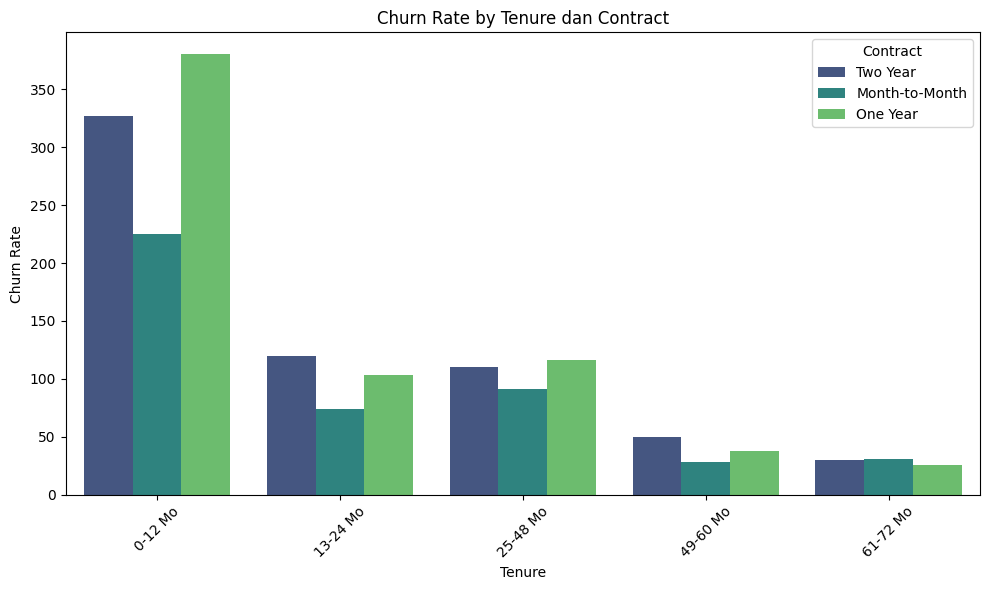

In [ ]:
bins = [0, 12, 24, 48, 60, 72]
labels = ['0-12 Mo', '13-24 Mo', '25-48 Mo', '49-60 Mo', '61-72 Mo']

df_multi1 = df0.copy()
df_multi1['tenure_group'] = pd.cut(df_multi1['tenure'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(10, 6))
sns.countplot(
    x='tenure_group',
    hue='Contract',
    data=df_multi1[df_multi1['Churn'] == 'Yes'],
    palette='viridis',
    order=labels
)
plt.title('Churn Rate by Tenure dan Contract')
plt.xlabel('Tenure')
plt.ylabel('Churn Rate')
plt.legend(title='Contract')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The chart shows that the 0–12 month period (first year) is the most critical phase, recording the highest number of churn events across all contract types. Notably, customers with long-term contracts (One Year and Two Year) also contribute substantially to churn within this early period, suggesting the presence of fundamental service or onboarding issues that drive even committed customers to leave prematurely.
Beyond the first year (13–24 months and later groups), the number of churn cases declines sharply across all contract types, indicating that once customers successfully pass the initial 12 months, they are significantly more likely to remain stable and retained.

#### 2. Average Monthly Charges by Senior Citizen and Churn

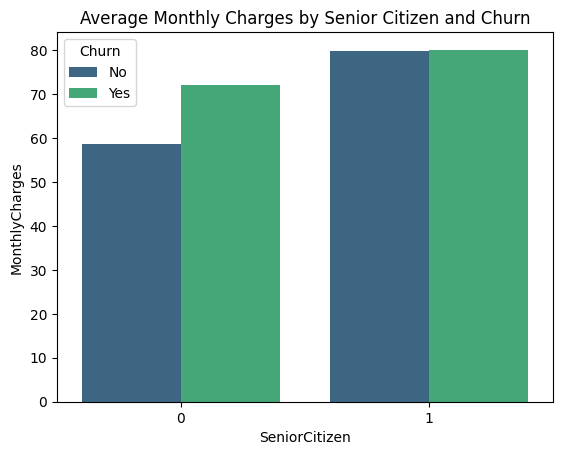

In [ ]:
plt.figure()
sns.barplot(
    data=df0,
    x='SeniorCitizen',
    y='MonthlyCharges',
    hue='Churn',
    palette='viridis',
    errorbar=None
)
plt.title('Average Monthly Charges by Senior Citizen and Churn')
plt.show()

Based on the analysis of the relationship between senior citizen status, monthly charges, and churn, it can be observed that customers who churn tend to have higher average monthly charges than those who do not churn, both among senior and non-senior customers. Among non-senior customers, the difference in average monthly charges between churned and retained customers is relatively clear, indicating that higher monthly charges increase the likelihood of customer churn. Meanwhile, for senior citizens, the average monthly charges remain relatively high for both churned and non-churned customers. However, seniors who churn still exhibit slightly higher monthly charges compared to those who remain subscribed.

## Feature Selection

We dropped CustomerID and Gender because these features do not have a significant impact on churn prediction. Additionally, TotalCharges was removed to prevent multicollinearity, ensuring our model remains stable and interpretable.

In [ ]:
df_dropped = df0.drop(columns = ['customerID', 'gender','TotalCharges'])
df_dropped.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,Yes,No,1.0,No,No phone service,Fiber Optic,No,Yes,No,No,No,No,Month-to-Month,Yes,Electronic check,29.85,No
1,0,No,No,34.0,Yes,No,Fiber Optic,Yes,No,Yes,No,No,No,Two Year,No,Mailed check,56.95,No
2,0,Yes,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Two Year,Yes,Mailed check,53.85,Yes
3,0,Yes,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One Year,No,Bank transfer (automatic),42.30,No
4,0,No,NaN,2.0,Yes,No,Fiber Optic,No,No,No,No,No,No,Month-to-Month,Yes,Electronic check,70.70,Yes


## Splitting Dataset

The dataset is split into 80% training and 20% testing sets using (`test_size=0.2`). The `random_state=42` ensures reproducibility, and `stratify=y` preserves the original distribution of the target classes in both training and testing sets. This is important to prevent class imbalance issues during model training and evaluation.

In [ ]:
x = df_dropped.drop('Churn', axis = 1)
y = df_dropped['Churn']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

In [ ]:
x_train.shape

(5627, 17)

In [ ]:
x_test.shape

(1407, 17)

## Handling Missing Values

In [ ]:
x_train.isnull().sum()

,0
SeniorCitizen,0
Partner,0
Dependents,351
tenure,364
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0


The x_train dataset contains missing values in several columns. Specifically, there are 351 missing entries in Dependents, 364 in tenure, 404 in PaperlessBilling, and 332 in MonthlyCharges. All other columns have no missing values.


In [ ]:
x_test.isnull().sum()

,0
SeniorCitizen,0
Partner,0
Dependents,102
tenure,91
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0


The x_test dataset contains missing values in several columns. Specifically, there are 102 missing entries in Dependents, 91 in tenure, 89 in PaperlessBilling, and 73 in MonthlyCharges. All other columns have no missing values.

### Numerical Missing Values

For numerical columns, we use **median** to fill missing entries because the data is not normally distributed. The median is preferred over the mean in this case because it is less affected by extreme values.

In [ ]:
# Impute tenure with median value
x_train['tenure'] = x_train['tenure'].fillna(x_train['tenure'].median())
x_test['tenure'] = x_test['tenure'].fillna(x_train['tenure'].median())

In [ ]:
# Impute MonthlyCharges with median value
x_train['MonthlyCharges'] = x_train['MonthlyCharges'].fillna(x_train['MonthlyCharges'].median())
x_test['MonthlyCharges'] = x_test['MonthlyCharges'].fillna(x_train['MonthlyCharges'].median())

### Categorical Missing Values

For categorical columns, we use **mode** to fill missing entries, which is the category that appears most frequently in the column.

In [ ]:
# Impute Dependents with its mode
x_train['Dependents'] = x_train['Dependents'].fillna(x_train['Dependents'].mode()[0])
x_test['Dependents'] = x_test['Dependents'].fillna(x_train['Dependents'].mode()[0])

In [ ]:
# Impute PaperlessBilling with its mode
x_train['PaperlessBilling'] = x_train['PaperlessBilling'].fillna(x_train['PaperlessBilling'].mode()[0])
x_test['PaperlessBilling'] = x_test['PaperlessBilling'].fillna(x_train['PaperlessBilling'].mode()[0])

## Feature Engineering

### Encode

For categorical feature whose values is binary (Yes/No), which is Partner, Dependents, PhoneService, and PaperlessBilling, will be encode using Label Encoding. We will also encode target column (Churn) using Label Encoding because its values is binary. Label Encoding keeps the representation simple and appropriate for binary information.

In [ ]:
le = LabelEncoder()

# Encode feature
feat_lab_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
x_train_labenc = x_train.copy()
x_test_labenc = x_test.copy()

for col in feat_lab_cols:
    x_train_labenc[col] = le.fit_transform(x_train[col])
    x_test_labenc[col] = le.transform(x_test[col])


y_train_fin = le.fit_transform(y_train)
y_test_fin = le.transform(y_test)

For nominal column, such as MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaymentMethod will use One Hot Encoding to avoid introducing artificial ordinal relationships between categories.

In [ ]:
ohe_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
ohe = OneHotEncoder(handle_unknown = "ignore", sparse_output = False)
train_ohe =  ohe.fit_transform(x_train_labenc[ohe_cols])
test_ohe =  ohe.transform(x_test_labenc[ohe_cols])

df_train = pd.DataFrame(train_ohe, columns = ohe.get_feature_names_out(ohe_cols), index = x_train_labenc.index)
df_test = pd.DataFrame(test_ohe, columns = ohe.get_feature_names_out(ohe_cols), index = x_test_labenc.index)

x_train_labenc = x_train_labenc.drop(columns = ohe_cols)
x_test_labenc = x_test_labenc.drop(columns = ohe_cols)

x_train_enc = pd.concat([x_train_labenc, df_train], axis = 1)
x_test_enc = pd.concat([x_test_labenc, df_test], axis = 1)

### Scaling
MonthlyCharges has a different scale compared to other numerical feature and the encoded variable. Therefore, scaling is required. Robust scaling is applied because it is less sensitive to outliers and uses the median and interquartile range, making it more suitable for data that may contain extreme values.

In [ ]:
robust_scaler = RobustScaler()
x_train_enc['MonthlyCharges_scaled'] = robust_scaler.fit_transform(x_train_enc[['MonthlyCharges']])
x_test_enc['MonthlyCharges_scaled'] = robust_scaler.transform(x_test_enc[['MonthlyCharges']])

# for training, we will only use MonthlyCharges_scaled and drop MonthlyCharges.
# But we will copy the dataset to new variable to make sure real MonthlyCharges column still available
x_train_sc = x_train_enc.copy()
x_test_sc = x_test_enc.copy()

x_train_sc.drop('MonthlyCharges', axis = 1, inplace = True)
x_test_sc.drop('MonthlyCharges', axis = 1, inplace = True)

### PCA
After encoding, the number of features increased to more than 30. To reduce dimensionality and computational complexity, Principal Component Analysis (PCA) was applied. The elbow method was used to determine the optimal number of principal components by analyzing the cumulative explained variance and identifying the point where adding more components provides diminishing returns.

90% variance achieve at 1 component
95% variance achieve at 1 component
99% variance achieve at 2 component


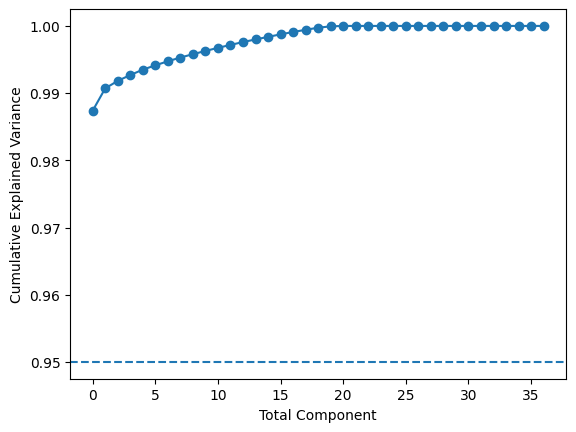

In [ ]:
pca_full = PCA(random_state=42)
pca_full.fit(x_train_sc)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

for t in [0.9, 0.95, 0.99]:
    k = np.argmax(cum_var >= t) + 1
    print(f"{int(t*100)}% variance achieve at {k} component")

plt.plot(cum_var, marker='o')
plt.axhline(y=0.95, linestyle='--')
plt.xlabel("Total Component")
plt.ylabel("Cumulative Explained Variance")
plt.show()


From the plot above, we observe that the cumulative explained variance increases rapidly at the beginning and then starts to level off. The elbow occurs at two components, where additional components provide only marginal gains in explained variance. Therefore, the number of PCA components is set to 2.

In [ ]:
pca = PCA(n_components=2, random_state=42)

x_train_fin = pca.fit_transform(x_train_sc)

x_test_fin = pca.transform(x_test_sc)

print("Total features before PCA:", x_train_sc.shape[1])
print("Total PCA component:", x_train_fin.shape[1])

explained_variance = pca.explained_variance_ratio_
print(f"Explained variance ratio of components: {explained_variance}")
print(f"Total explained variance: {sum(explained_variance):.2f}")

Total features before PCA: 37
Total PCA component: 2
Explained variance ratio of components: [0.98739293 0.00331228]
Total explained variance: 0.99


## Modeling
Because this dataset has imbalance target, so we need to use class weighting parameters (class_weight = 'balanced', scale_post_weight in XGBoost, etc) or SMOTE (Synthetic Minority Over-sampling Technique). In this project, we will compare performance metric between these two method.

### Using SMOTE


In [ ]:
smote = SMOTE(
    sampling_strategy='auto',
    random_state=42,
    k_neighbors=5
)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train_fin, y_train_fin
)

y_train_series = pd.Series(y_train_fin)

print("Before SMOTE:")
print(y_train_series.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())


Before SMOTE:
0    4132
1    1495
Name: count, dtype: int64

After SMOTE:
0    4132
1    4132
Name: count, dtype: int64


#### Logistic Regression

In [ ]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(x_train_smote, y_train_smote)

lr_y_pred = lr_model.predict(x_test_fin)

print("Confusion matrix : ")
print(confusion_matrix(y_test_fin, lr_y_pred))
print("\nClassification report : ")
print(classification_report(y_test_fin, lr_y_pred))

Confusion matrix : 
[[707 326]
 [ 83 291]]

Classification report : 
              precision    recall  f1-score   support

           0       0.89      0.68      0.78      1033
           1       0.47      0.78      0.59       374

    accuracy                           0.71      1407
   macro avg       0.68      0.73      0.68      1407
weighted avg       0.78      0.71      0.73      1407



#### SVC

In [ ]:
svc_model = SVC(random_state=42)
svc_model.fit(x_train_smote, y_train_smote)

svc_y_pred = svc_model.predict(x_test_fin)

print("Confusion matrix : ")
print(confusion_matrix(y_test_fin, svc_y_pred))
print("\nClassification report : ")
print(classification_report(y_test_fin, svc_y_pred))

Confusion matrix : 
[[671 362]
 [ 79 295]]

Classification report : 
              precision    recall  f1-score   support

           0       0.89      0.65      0.75      1033
           1       0.45      0.79      0.57       374

    accuracy                           0.69      1407
   macro avg       0.67      0.72      0.66      1407
weighted avg       0.78      0.69      0.70      1407



#### Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier(random_state = 42)
dt_model = dt_model.fit(x_train_smote, y_train_smote)

dt_y_pred = dt_model.predict(x_test_fin)

print("Confusion matrix : ")
print(confusion_matrix(y_test_fin, dt_y_pred))
print("\nClassification report : ")
print(classification_report(y_test_fin, dt_y_pred))

Confusion matrix : 
[[799 234]
 [161 213]]

Classification report : 
              precision    recall  f1-score   support

           0       0.83      0.77      0.80      1033
           1       0.48      0.57      0.52       374

    accuracy                           0.72      1407
   macro avg       0.65      0.67      0.66      1407
weighted avg       0.74      0.72      0.73      1407



#### Naive Bayes

In [ ]:
nb_model = GaussianNB()
nb_model.fit(x_train_smote, y_train_smote)

nb_y_pred = nb_model.predict(x_test_fin)

print("Confusion matrix : ")
print(confusion_matrix(y_test_fin, nb_y_pred))
print("\nClassification report : ")
print(classification_report(y_test_fin, nb_y_pred))

Confusion matrix : 
[[621 412]
 [ 66 308]]

Classification report : 
              precision    recall  f1-score   support

           0       0.90      0.60      0.72      1033
           1       0.43      0.82      0.56       374

    accuracy                           0.66      1407
   macro avg       0.67      0.71      0.64      1407
weighted avg       0.78      0.66      0.68      1407



#### KNN

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(x_train_smote, y_train_smote)

knn_y_pred = knn_model.predict(x_test_fin)

print("Confusion matrix : ")
print(confusion_matrix(y_test_fin, knn_y_pred))
print("\nClassification report : ")
print(classification_report(y_test_fin, knn_y_pred))

Confusion matrix : 
[[786 247]
 [129 245]]

Classification report : 
              precision    recall  f1-score   support

           0       0.86      0.76      0.81      1033
           1       0.50      0.66      0.57       374

    accuracy                           0.73      1407
   macro avg       0.68      0.71      0.69      1407
weighted avg       0.76      0.73      0.74      1407



#### Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train_smote, y_train_smote)

rf_y_pred = rf_model.predict(x_test_fin)

print("Confusion matrix : ")
print(confusion_matrix(y_test_fin, rf_y_pred))
print("\nClassification report : ")
print(classification_report(y_test_fin, rf_y_pred))

Confusion matrix : 
[[810 223]
 [140 234]]

Classification report : 
              precision    recall  f1-score   support

           0       0.85      0.78      0.82      1033
           1       0.51      0.63      0.56       374

    accuracy                           0.74      1407
   macro avg       0.68      0.70      0.69      1407
weighted avg       0.76      0.74      0.75      1407



#### CatBoost

In [ ]:
cat_model = CatBoostClassifier(learning_rate=0.03, random_state = 42)
cat_model.fit(x_train_smote, y_train_smote)

cat_y_pred = cat_model.predict(x_test_fin)

0:	learn: 0.6806538	total: 33.6ms	remaining: 33.6s
1:	learn: 0.6689472	total: 44.9ms	remaining: 22.4s
2:	learn: 0.6580116	total: 52.9ms	remaining: 17.6s
3:	learn: 0.6480607	total: 60.6ms	remaining: 15.1s
4:	learn: 0.6384679	total: 69.8ms	remaining: 13.9s
5:	learn: 0.6293378	total: 77.7ms	remaining: 12.9s
6:	learn: 0.6207925	total: 87.8ms	remaining: 12.5s
7:	learn: 0.6126265	total: 95.9ms	remaining: 11.9s
8:	learn: 0.6052781	total: 104ms	remaining: 11.4s
9:	learn: 0.5985415	total: 112ms	remaining: 11.1s
10:	learn: 0.5925473	total: 121ms	remaining: 10.9s
11:	learn: 0.5866073	total: 128ms	remaining: 10.5s
12:	learn: 0.5811899	total: 136ms	remaining: 10.3s
13:	learn: 0.5756749	total: 144ms	remaining: 10.2s
14:	learn: 0.5705068	total: 152ms	remaining: 9.99s
15:	learn: 0.5655939	total: 160ms	remaining: 9.85s
16:	learn: 0.5613482	total: 168ms	remaining: 9.72s
17:	learn: 0.5570304	total: 176ms	remaining: 9.61s
18:	learn: 0.5531390	total: 184ms	remaining: 9.51s
19:	learn: 0.5500062	total: 193ms

In [ ]:
print("Confusion matrix : ")
print(confusion_matrix(y_test_fin, cat_y_pred))
print("\nClassification report : ")
print(classification_report(y_test_fin, cat_y_pred))

Confusion matrix : 
[[787 246]
 [100 274]]

Classification report : 
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1033
           1       0.53      0.73      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.75      0.76      1407



#### XGBoost

In [ ]:
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(x_train_smote, y_train_smote)

xgb_y_pred = xgb_model.predict(x_test_fin)

print("Confusion Matrix:")
print(confusion_matrix(y_test_fin, xgb_y_pred))
print("\nClassification Report:")
print(classification_report(y_test_fin, xgb_y_pred))

Confusion Matrix:
[[788 245]
 [105 269]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1033
           1       0.52      0.72      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407



#### LightGBM

In [ ]:
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(x_train_smote, y_train_smote)

lgbm_y_pred = lgbm_model.predict(x_test_fin)

[LightGBM] [Info] Number of positive: 4132, number of negative: 4132
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001273 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 8264, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test_fin, lgbm_y_pred))
print("\nClassification Report:")
print(classification_report(y_test_fin, lgbm_y_pred))

Confusion Matrix:
[[777 256]
 [ 96 278]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.75      0.82      1033
           1       0.52      0.74      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.79      0.75      0.76      1407



#### AdaBoost

In [ ]:
ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(x_train_smote, y_train_smote)

ada_y_pred = ada_model.predict(x_test_fin)

print("Confusion Matrix:")
print(confusion_matrix(y_test_fin, ada_y_pred))
print("\nClassification Report:")
print(classification_report(y_test_fin, ada_y_pred))

Confusion Matrix:
[[720 313]
 [ 82 292]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.70      0.78      1033
           1       0.48      0.78      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.73      1407



#### Gradient Boosting

In [ ]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(x_train_smote, y_train_smote)

gb_y_pred = gb_model.predict(x_test_fin)

print("Confusion Matrix:")
print(confusion_matrix(y_test_fin, gb_y_pred))
print("\nClassification Report:")
print(classification_report(y_test_fin, gb_y_pred))

Confusion Matrix:
[[779 254]
 [ 87 287]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1033
           1       0.53      0.77      0.63       374

    accuracy                           0.76      1407
   macro avg       0.72      0.76      0.72      1407
weighted avg       0.80      0.76      0.77      1407



### Using Class Weighting Parameters

#### Logistic Regression

In [ ]:
lr_model2 = LogisticRegression(random_state=42, class_weight="balanced")
lr_model2.fit(x_train_fin, y_train_fin)

lr_y_pred2 = lr_model2.predict(x_test_fin)

print("Confusion matrix : ")
print(confusion_matrix(y_test_fin, lr_y_pred2))
print("\nClassification report : ")
print(classification_report(y_test_fin, lr_y_pred2))

Confusion matrix : 
[[703 330]
 [ 83 291]]

Classification report : 
              precision    recall  f1-score   support

           0       0.89      0.68      0.77      1033
           1       0.47      0.78      0.58       374

    accuracy                           0.71      1407
   macro avg       0.68      0.73      0.68      1407
weighted avg       0.78      0.71      0.72      1407



#### SVC

In [ ]:
svc_model2 = SVC(class_weight="balanced")
svc_model2.fit(x_train_fin, y_train_fin)

svc_y_pred2 = svc_model2.predict(x_test_fin)

print("Confusion matrix : ")
print(confusion_matrix(y_test_fin, svc_y_pred2))
print("\nClassification report : ")
print(classification_report(y_test_fin, svc_y_pred2))

Confusion matrix : 
[[673 360]
 [ 79 295]]

Classification report : 
              precision    recall  f1-score   support

           0       0.89      0.65      0.75      1033
           1       0.45      0.79      0.57       374

    accuracy                           0.69      1407
   macro avg       0.67      0.72      0.66      1407
weighted avg       0.78      0.69      0.71      1407



#### Decision Tree

In [ ]:
dt_model2 = DecisionTreeClassifier(random_state = 42, class_weight = "balanced")
dt_model2.fit(x_train_fin, y_train_fin)

dt_y_pred2 = dt_model2.predict(x_test_fin)

print("Confusion matrix : ")
print(confusion_matrix(y_test_fin, dt_y_pred2))
print("\nClassification report : ")
print(classification_report(y_test_fin, dt_y_pred2))

Confusion matrix : 
[[846 187]
 [192 182]]

Classification report : 
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1033
           1       0.49      0.49      0.49       374

    accuracy                           0.73      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.73      0.73      0.73      1407



#### Random Forest

In [ ]:
rf_model2 = RandomForestClassifier(n_estimators=100, class_weight="balanced")
rf_model2.fit(x_train_fin, y_train_fin)

rf_y_pred2 = rf_model2.predict(x_test_fin)

print("Confusion matrix : ")
print(confusion_matrix(y_test_fin, rf_y_pred2))
print("\nClassification report : ")
print(classification_report(y_test_fin, rf_y_pred2))

Confusion matrix : 
[[914 119]
 [198 176]]

Classification report : 
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1033
           1       0.60      0.47      0.53       374

    accuracy                           0.77      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.76      0.77      0.77      1407



#### XGBoost

In [ ]:
n_neg = np.sum(y_train_fin == 0)
n_pos = np.sum(y_train_fin == 1)

scale_pos_weight = n_neg / n_pos
print(scale_pos_weight)

2.7638795986622076


In [ ]:
xgb_model2 = XGBClassifier(random_state=42, scale_pos_weight = scale_pos_weight)
xgb_model2.fit(x_train_fin, y_train_fin)

xgb_y_pred2 = xgb_model2.predict(x_test_fin)

print("Confusion Matrix:")
print(confusion_matrix(y_test_fin, xgb_y_pred2))
print("\nClassification Report:")
print(classification_report(y_test_fin, xgb_y_pred2))

Confusion Matrix:
[[793 240]
 [119 255]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.77      0.82      1033
           1       0.52      0.68      0.59       374

    accuracy                           0.74      1407
   macro avg       0.69      0.72      0.70      1407
weighted avg       0.78      0.74      0.75      1407



#### LightGBM

In [ ]:
lgbm_model2 = LGBMClassifier(random_state=42, class_weight='balanced')
lgbm_model2.fit(x_train_fin, y_train_fin)

lgbm_y_pred2 = lgbm_model2.predict(x_test_fin)

[LightGBM] [Info] Number of positive: 1495, number of negative: 4132
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000331 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 5627, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test_fin, lgbm_y_pred2))
print("\nClassification Report:")
print(classification_report(y_test_fin, lgbm_y_pred2))

Confusion Matrix:
[[774 259]
 [ 98 276]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1033
           1       0.52      0.74      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407



#### AdaBoost

In [ ]:
ada_model2 = AdaBoostClassifier(random_state=42, estimator=DecisionTreeClassifier(class_weight='balanced'))
ada_model2.fit(x_train_fin, y_train_fin)

ada_y_pred2 = ada_model2.predict(x_test_fin)

print("Confusion Matrix:")
print(confusion_matrix(y_test_fin, ada_y_pred2))
print("\nClassification Report:")
print(classification_report(y_test_fin, ada_y_pred2))

Confusion Matrix:
[[857 176]
 [200 174]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      1033
           1       0.50      0.47      0.48       374

    accuracy                           0.73      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.73      0.73      0.73      1407



#### Gradient Boosting

In [ ]:
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_fin
)

gb_model2 = GradientBoostingClassifier(random_state=42)
gb_model2.fit(x_train_fin, y_train_fin, sample_weight = sample_weights)

gb_y_pred2 = gb_model2.predict(x_test_fin)

print("Confusion Matrix:")
print(confusion_matrix(y_test_fin, gb_y_pred2))
print("\nClassification Report:")
print(classification_report(y_test_fin, gb_y_pred2))

Confusion Matrix:
[[770 263]
 [ 90 284]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.75      0.81      1033
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.80      0.75      0.76      1407



In churn prediction, the primary objective is to correctly identify customers who are likely to churn. Therefore, recall for the churn class (class 1) is a critical metric, as it measures the model’s ability to capture actual churners and minimize false negatives. Missing a churn customer represents a significant business risk, as it prevents timely retention actions.
Precision for the non-churn class (class 0) is also important to ensure that customers predicted as safe are indeed not at risk of churn. Low precision for class 0 would indicate that many churners are mistakenly classified as loyal customers.


## Model Comparison

In [ ]:
models = [
    'Logistic Regression', 'SVC', 'Decision Tree', 'Naive Bayes', 'KNN',
    'Random Forest', 'CatBoost', 'XGBoost', 'LightGBM',
    'AdaBoost', 'Gradient Boosting'
]

columns = pd.MultiIndex.from_product(
    [['SMOTE', 'Class Weighting Parameter'],
     ['Precision 0', 'Recall 1']]
)

results_df = pd.DataFrame(index=models, columns=columns)

def extract_metrics(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return report['0']['precision'], report['1']['recall']


In [ ]:
#Logistic Regression
#SMOTE
lr_sp0, lr_sr1 = extract_metrics(y_test_fin, lr_y_pred)

results_df.loc['Logistic Regression', ('SMOTE', 'Precision 0')] = lr_sp0
results_df.loc['Logistic Regression', ('SMOTE', 'Recall 1')] = lr_sr1

#Class Weighting Parameter
lr_cp0, lr_cr1 = extract_metrics(y_test_fin, lr_y_pred2)

results_df.loc['Logistic Regression', ('Class Weighting Parameter', 'Precision 0')] = lr_cp0
results_df.loc['Logistic Regression', ('Class Weighting Parameter', 'Recall 1')] = lr_cr1

#SVC
#SMOTE
svc_sp0, svc_sr1 = extract_metrics(y_test_fin, svc_y_pred)

results_df.loc['SVC', ('SMOTE', 'Precision 0')] = svc_sp0
results_df.loc['SVC', ('SMOTE', 'Recall 1')] = svc_sr1

#Class Weighting Parameter
svc_cp0, svc_cr1 = extract_metrics(y_test_fin, svc_y_pred2)

results_df.loc['SVC', ('Class Weighting Parameter', 'Precision 0')] = svc_cp0
results_df.loc['SVC', ('Class Weighting Parameter', 'Recall 1')] = svc_cr1

#Decision Tree
#SMOTE
dt_sp0, dt_sr1 = extract_metrics(y_test_fin, dt_y_pred)

results_df.loc['Decision Tree', ('SMOTE', 'Precision 0')] = dt_sp0
results_df.loc['Decision Tree', ('SMOTE', 'Recall 1')] = dt_sr1

#Class Weighting Parameter
dt_cp0, dt_cr1 = extract_metrics(y_test_fin, dt_y_pred2)

results_df.loc['Decision Tree', ('Class Weighting Parameter', 'Precision 0')] = dt_cp0
results_df.loc['Decision Tree', ('Class Weighting Parameter', 'Recall 1')] = dt_cr1

#Naive Bayes
#SMOTE
nb_sp0, nb_sr1 = extract_metrics(y_test_fin, nb_y_pred)

results_df.loc['Naive Bayes', ('SMOTE', 'Precision 0')] = nb_sp0
results_df.loc['Naive Bayes', ('SMOTE', 'Recall 1')] = nb_sr1

#Class Weighting Parameter
results_df.loc['Naive Bayes', ('Class Weighting Parameter', 'Precision 0')] = 0
results_df.loc['Naive Bayes', ('Class Weighting Parameter', 'Recall 1')] = 0

#KNN
#SMOTE
knn_sp0, knn_sr1 = extract_metrics(y_test_fin, knn_y_pred)

results_df.loc['KNN', ('SMOTE', 'Precision 0')] = knn_sp0
results_df.loc['KNN', ('SMOTE', 'Recall 1')] = knn_sr1

#Class Weighting Parameter
results_df.loc['KNN', ('Class Weighting Parameter', 'Precision 0')] = 0
results_df.loc['KNN', ('Class Weighting Parameter', 'Recall 1')] = 0

#Random Forest
#SMOTE
rf_sp0, rf_sr1 = extract_metrics(y_test_fin, rf_y_pred)

results_df.loc['Random Forest', ('SMOTE', 'Precision 0')] = rf_sp0
results_df.loc['Random Forest', ('SMOTE', 'Recall 1')] = rf_sr1

#Class Weighting Parameter
rf_cp0, rf_cr1 = extract_metrics(y_test_fin, rf_y_pred2)

results_df.loc['Random Forest', ('Class Weighting Parameter', 'Precision 0')] = rf_cp0
results_df.loc['Random Forest', ('Class Weighting Parameter', 'Recall 1')] = rf_cr1

#CatBoost
#SMOTE
cat_sp0, cat_sr1 = extract_metrics(y_test_fin, cat_y_pred)

results_df.loc['CatBoost', ('SMOTE', 'Precision 0')] = cat_sp0
results_df.loc['CatBoost', ('SMOTE', 'Recall 1')] = cat_sr1

#Class Weighting Parameter
results_df.loc['CatBoost', ('Class Weighting Parameter', 'Precision 0')] = 0
results_df.loc['CatBoost', ('Class Weighting Parameter', 'Recall 1')] = 0

#XGBoost
#SMOTE
xgb_sp0, xgb_sr1 = extract_metrics(y_test_fin, xgb_y_pred)

results_df.loc['XGBoost', ('SMOTE', 'Precision 0')] = xgb_sp0
results_df.loc['XGBoost', ('SMOTE', 'Recall 1')] = xgb_sr1

#Class Weighting Parameter
xgb_cp0, xgb_cr1 = extract_metrics(y_test_fin, xgb_y_pred2)

results_df.loc['XGBoost', ('Class Weighting Parameter', 'Precision 0')] = xgb_cp0
results_df.loc['XGBoost', ('Class Weighting Parameter', 'Recall 1')] = xgb_cr1

#LightGBM
#SMOTE
lgbm_sp0, lgbm_sr1 = extract_metrics(y_test_fin, lgbm_y_pred)

results_df.loc['LightGBM', ('SMOTE', 'Precision 0')] = lgbm_sp0
results_df.loc['LightGBM', ('SMOTE', 'Recall 1')] = lgbm_sr1

#Class Weighting Parameter
lgbm_cp0, lgbm_cr1 = extract_metrics(y_test_fin, lgbm_y_pred2)

results_df.loc['LightGBM', ('Class Weighting Parameter', 'Precision 0')] = lgbm_cp0
results_df.loc['LightGBM', ('Class Weighting Parameter', 'Recall 1')] = lgbm_cr1

#AdaBoost
#SMOTE
ada_sp0, ada_sr1 = extract_metrics(y_test_fin, ada_y_pred)

results_df.loc['AdaBoost', ('SMOTE', 'Precision 0')] = ada_sp0
results_df.loc['AdaBoost', ('SMOTE', 'Recall 1')] = ada_sr1

#Class Weighting Parameter
ada_cp0, ada_cr1 = extract_metrics(y_test_fin, ada_y_pred2)

results_df.loc['AdaBoost', ('Class Weighting Parameter', 'Precision 0')] = ada_cp0
results_df.loc['AdaBoost', ('Class Weighting Parameter', 'Recall 1')] = ada_cr1

#Gradient Boosting
#SMOTE
gb_sp0, gb_sr1 = extract_metrics(y_test_fin, gb_y_pred)

results_df.loc['Gradient Boosting', ('SMOTE', 'Precision 0')] = gb_sp0
results_df.loc['Gradient Boosting', ('SMOTE', 'Recall 1')] = gb_sr1

#Class Weighting Parameter
gb_cp0, gb_cr1 = extract_metrics(y_test_fin, gb_y_pred2)

results_df.loc['Gradient Boosting', ('Class Weighting Parameter', 'Precision 0')] = gb_cp0
results_df.loc['Gradient Boosting', ('Class Weighting Parameter', 'Recall 1')] = gb_cr1

In [ ]:
results_df = results_df.astype(float).round(3)
results_df


SMOTE          Class Weighting Parameter         
                    Precision 0 Recall 1               Precision 0 Recall 1
Logistic Regression       0.895    0.778                     0.894    0.778
SVC                       0.895    0.789                     0.895    0.789
Decision Tree             0.832    0.570                     0.815    0.487
Naive Bayes               0.904    0.824                     0.000    0.000
KNN                       0.859    0.655                     0.000    0.000
Random Forest             0.853    0.626                     0.822    0.471
CatBoost                  0.887    0.733                     0.000    0.000
XGBoost                   0.882    0.719                     0.870    0.682
LightGBM                  0.890    0.743                     0.888    0.738
AdaBoost                  0.898    0.781                     0.811    0.465
Gradient Boosting         0.900    0.767                     0.895    0.759

Model with precision and recall 0.000 in Class Weighting Parameter column represent that those model doesn't have class weighting parameter, such as class_weight, scale_post_weight, etc.

From the table above, we can observe that the model trained with SMOTE achieves higher precision for class 0 (non-churn) and higher recall for class 1 (churn) compared to the model using Class Weighting Parameters. This indicates that SMOTE handles class imbalance more effectively.

SMOTE improves performance by generating synthetic samples for the minority (churn) class based on existing data patterns. By increasing the representation of churn samples, the model can learn churn-related patterns more clearly, which leads to better classification performance, especially in terms of recall.

Based on the model comparison results above, Naive Bayes achieved the best performance, followed by Support Vector Classifier (SVC), AdaBoost, and Logistic Regression.

## Hyperparameter Tuning

Hyperparameter tuning is performed on the 4 best-performing models to improve their predictive performance and robustness. For each model, a set of hyperparameters is systematically explored to identify the optimal configuration. This process aims to reduce overfitting, enhance generalization to unseen data, and ensure fair comparison across models. The model with the best evaluation metrics after tuning is selected as the final model.

### SVC

In [ ]:
svc = SVC(random_state=42)

param_grid_scv = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': [ 0.1, 1]
}

grid_scv = GridSearchCV(
    estimator=svc,
    param_grid=param_grid_scv,
    scoring='recall',
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_scv.fit(x_train_smote, y_train_smote)

print("Best Params:", grid_scv.best_params_)
print("Best Score:", grid_scv.best_score_)

scv_tuned_pred = grid_scv.predict(x_test_fin)
print("\nClassification Report:")
print(classification_report(y_test_fin, scv_tuned_pred))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
Best Score: 0.8400262332711659

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1033
           1       0.49      0.77      0.60       374

    accuracy                           0.73      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.79      0.73      0.74      1407



### Naive Bayes

In [ ]:
gnb = GaussianNB()

param_grid_gnb = {
    'var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8]
}

grid_gnb = GridSearchCV(
    estimator=gnb,
    param_grid=param_grid_gnb,
    scoring='recall',   # cocok untuk churn
    cv=5,
    n_jobs=-1
)

grid_gnb.fit(x_train_smote, y_train_smote)

print("Best Params:", grid_gnb.best_params_)
print("Best CV Score:", grid_gnb.best_score_)

gnb_tuned_pred = grid_gnb.predict(x_test_fin)

print("\nClassification Report:")
print(classification_report(y_test_fin, gnb_tuned_pred))

Best Params: {'var_smoothing': 1e-12}
Best CV Score: 0.8315548776024665

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.60      0.72      1033
           1       0.43      0.82      0.56       374

    accuracy                           0.66      1407
   macro avg       0.67      0.71      0.64      1407
weighted avg       0.78      0.66      0.68      1407



### AdaBoost

In [ ]:
base_estimator = DecisionTreeClassifier(random_state=42)

ada = AdaBoostClassifier(
    estimator=base_estimator,
    random_state=42
)

param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1],
    'estimator__max_depth': [1, 2, 3]
}

grid_ada = GridSearchCV(
    estimator=ada,
    param_grid=param_grid_ada,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_ada.fit(x_train_smote, y_train_smote)

print("Best Parameters:", grid_ada.best_params_)
print("Best Score:", grid_ada.best_score_)

# Prediction
ada_tuned_pred = grid_ada.predict(x_test_fin)

print("\nClassification Report:")
print(classification_report(y_test_fin, ada_tuned_pred))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters: {'estimator__max_depth': 1, 'learning_rate': 0.01, 'n_estimators': 100}
Best Score: 0.829621344982155

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.60      0.72      1033
           1       0.42      0.81      0.56       374

    accuracy                           0.65      1407
   macro avg       0.66      0.71      0.64      1407
weighted avg       0.77      0.65      0.67      1407



### Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=500)

param_grid_lr = {
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'C': [0.001, 0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'saga'],
    'l1_ratio': [0, 0.5, 1]
}

grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(x_train_smote, y_train_smote)

print("Best Params:", grid_lr.best_params_)
print("Best Score:", grid_lr.best_score_)

lr_tunned_pred = grid_lr.predict(x_test_fin)
print("\nClassification Report:")
print(classification_report(y_test_fin, lr_tunned_pred))

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Params: {'C': 0.001, 'l1_ratio': 0, 'penalty': 'l1', 'solver': 'liblinear'}
Best Score: 0.8223565441178623

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.57      0.70      1033
           1       0.42      0.86      0.56       374

    accuracy                           0.65      1407
   macro avg       0.67      0.71      0.63      1407
weighted avg       0.78      0.65      0.67      1407



Hyperparameter tuning did not result in a significant performance improvement for the SVC, Naive Bayes, and AdaBoost models. This suggests that these models are either already operating near their optimal configurations with default parameters or that their performance is less sensitive to hyperparameter adjustments on this dataset. Nevertheless, tuning remains important to improve model robustness and stability when deployed in real world settings.   

Logistic Regression emerged as the best performing model after hyperparameter tuning, particularly when optimizing for recall, which is the primary metric in churn prediction. This indicates that Logistic Regression benefits more substantially from regularization and parameter optimization in handling the characteristics of the churn dataset.

WHY LOGISTIC REGRESSION??

The combination of strong regularization (C = 0.001) and pure L1 penalty indicates that the optimal Logistic Regression model for this churn dataset prioritizes simplicity, robustness, and generalization. This configuration effectively removes irrelevant features, reduces overfitting, and improves recall, making it highly suitable for identifying potential churners.

## Conclusion

SMOTE achieved better performance metrics than Class Weighting Parameter by more effectively addressing class imbalance. With this improvement, Logistic Regression emerged as the best-performing model after model comparison and hyperparameter tuning, particularly in improving recall, which is crucial for identifying churn customers. With strong regularization, Logistic Regression remains simple, robust, and generalizable, making it a reliable approach for churn prediction in this dataset.